# Step 5: Enzyme annotation and DNA design

This notebook is the final step of the SynThera pipeline. It consumes the outputs
of Steps 1-4 and delivers experiment-ready DNA constructs for the top predicted
antiviral compounds.

**Step 5A** — Pathway reconstruction (run from the terminal, outside this notebook).
**Step 5B** — Analysis inside this notebook: enzymatic reaction filtering, DORA-XGB
feasibility scoring, RCMFP-guided enzyme retrieval, UniProt metadata, GenBank DNA
sequences, codon optimization, and FASTA export.

Files consumed from earlier steps:

| Step | File | Purpose |
|---|---|---|
| Step 4 | `{target}_generatedCompounds_top{N}.csv` | target compound list for pathway jobs |
| Step 3 | `{target}_allGeneratedCompounds_combined.csv` | starter SMILES lookup |
| Input_Data | `JN3604IMT_rules.tsv` | DORAnet reaction ruleset |
| Input_Data | `known_enzyme_reactions_union.parquet` | RCMFP reference enzymes |
| Input_Data | `known_rxn_rcmfp_cache.npz` | precomputed RCMFP fingerprints |

All results are written to `Results_{target}/`.

### Imports

In [46]:
from pathlib import Path
import glob
import json
import os
import re
import textwrap
import ast
import sys
import time
import yaml
import hashlib
import requests
import base64

import numpy as np
import pandas as pd
import pubchempy as pcp
from tqdm.auto import tqdm
from rdkit import Chem, rdBase
from rdkit.Chem import rdmolfiles, Draw, AllChem, Descriptors
from IPython.display import display, Markdown, HTML
from io import StringIO, BytesIO
from PIL import Image, ImageDraw, ImageFont
from Bio import Entrez, SeqIO

from DORA_XGB import DORA_XGB
byDescMW_model    = DORA_XGB.feasibility_classifier(cofactor_positioning="by_descending_MW")
byAscMW_model     = DORA_XGB.feasibility_classifier(cofactor_positioning="by_ascending_MW")
addConcat_model   = DORA_XGB.feasibility_classifier(cofactor_positioning="add_concat")
addSubtract_model = DORA_XGB.feasibility_classifier(cofactor_positioning="add_subtract")

from Bio.Data import CodonTable
from dnachisel import (
    DnaOptimizationProblem,
    EnforceTranslation,
    EnforceGCContent,
    AvoidPattern,
    MaximizeCAI,
)

tqdm.pandas()


def canonicalizeSmiles(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

## Job configuration

In [47]:
def findProjectRoot(startDir=None, marker="Input_Data"):
    """Walk upward until a folder containing `marker` is found."""
    current = os.path.abspath(startDir or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(current, marker)):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            raise FileNotFoundError(
                f"No project root containing '{marker}' above {os.getcwd()}")
        current = parent

projectRoot = findProjectRoot()

# Change target to any pathogen prepared by Steps 1-4.
target = "Ebola"
topN   = 20          # must match the topN used in Step 4

dataDir    = os.path.join(projectRoot, "Input_Data")
resultsDir = os.path.join(projectRoot, target, f"Results_{target}")
os.makedirs(resultsDir, exist_ok=True)

# Step 5A: pathway reconstruction jobs live here.
DORAnetPathwaysDir = os.path.join(resultsDir, "Step5_ExperimentalDesigns")
os.makedirs(DORAnetPathwaysDir, exist_ok=True)

# Input files from previous steps.
topNCompoundsFile    = os.path.join(resultsDir, f"{target}_generatedCompounds_top{topN}.csv")
allGeneratedFile     = os.path.join(resultsDir, f"{target}_allGeneratedCompounds_combined.csv")

# DORAnet reference data (inside Input_Data).
doranetRulesetFile       = os.path.join(projectRoot, "Input_Data", "JN3604IMT_rules.tsv")
knownEnzymeParquetFile   = os.path.join(projectRoot, "Input_Data", "known_enzyme_reactions_union.parquet")
knownEnzymeFpFile        = os.path.join(projectRoot, "Input_Data", "known_rxn_rcmfp_cache.npz")



NCBI_EMAIL   = "sghosh6@lbl.gov"     # set your email
NCBI_API_KEY = None                  # set to your NCBI API key for higher rate limits
NCBI_TOOL    = "DORAnet_GenBank_CDS_Fetch"

# Ergochemics source (RCMFP fingerprinting library).
ergochemicsSrc = os.environ.get(
    "ERGOCHEMICS_SRC",
    os.path.join(projectRoot, "external", "ergochemics", "src"),
)

print("Target:", target)
print("Results dir:", resultsDir)
print("DORAnet pathways dir:", DORAnetPathwaysDir)
print("Top compounds file:", topNCompoundsFile,
      "(found)" if os.path.exists(topNCompoundsFile) else "(MISSING)")
print("DORAnet ruleset:", doranetRulesetFile,
      "(found)" if os.path.exists(doranetRulesetFile) else "(MISSING)")

Target: Ebola
Results dir: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola
DORAnet pathways dir: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/Step5_ExperimentalDesigns
Top compounds file: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/Ebola_generatedCompounds_top20.csv (found)
DORAnet ruleset: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Input_Data/JN3604IMT_rules.tsv (found)


## Step 5A: Reconstruct biosynthetic pathways

This step runs **outside** the notebook. `doranet_pathways_multiGen.py` reads
the top-N target compounds from Step 4 and launches one DORAnet pathway-search
job per (starter, target) pair per generation, in parallel.

The config YAML below is written automatically. Copy `doranet_pathways_multiGen.py`
into `Step5_ExperimentalDesigns/` (or adjust the path), then run:

```bash
cd Results_{target}/Step5_ExperimentalDesigns
python doranet_pathways_multiGen.py config_doranet_multiGen.yaml > doranet.out
```

The script produces one subdirectory per job and writes `job_summary.csv` to
`Step5_ExperimentalDesigns/`. When the run finishes, proceed to Step 5B below.

In [48]:
# Auto-generate the DORAnet pathway config, reading the top-N CSV from Step 4.
doranetCfg = {
    # DORAnet checkout location (added to sys.path at runtime by the script).
    "doranetPath": str(os.path.join(projectRoot, "doranet")),
    "outputDir": ".",

    # Job naming.
    "baseJobPrefix": f"{target}_pathway",
    "generationSuffixTemplate": "_wGen{generation}",

    # Generation depths to run separately.
    "generationsToRun": [1, 2, 3],
    "searchDepthEqualsGeneration": True,
    "maxNumRxnsEqualsGeneration": True,
    "filterExactNumRxns": True,
    "exactNumRxnsEqualsGeneration": True,

    # Parallelism.
    "numParallelJobs": 16,
    "numProcess": 1,

    # Input CSV: top-N compounds from Step 4. The script reads startersColumn
    # and targetsColumn from this file.
    "targetsCsvPath": topNCompoundsFile,
    "startersColumn": "starter_Canonical_SMILES",
    "targetsColumn":  "Canonical_SMILES",

    # null = run all rows; set to a list of 1-based indices to restrict.
    "targetsToTest": None,

    # maxAtoms is computed per starter as ceil(atomCount * atomMultiplier).
    "atomMultiplier": 1.5,

    # Cofactor helpers.
    "helpers": [
        "C#N", "N", "S", "[H][H]", "O=S=O", "N#CO", "O=S(=O)(O)O",
        "[Br][Br]", "O=NO", "O", "C=O", "NO", "N#N", "CO",
        "O=[N+]([O-])O", "O=S(O)O", "Br", "O=O", "O=C=O", "[C-]#[O+]", "C=C",
    ],

    "direction": "forward",
    "ruleset": "JN3604IMT",
    "minRxnAtomEconomy": 0.0,
    "sanitize": True,
    "removePureHelpersRxns": False,
    "transformEnolsFlag": False,
    "considerNameDifference": True,
    "runRanking": True,
    "runVisualization": False,
    "summaryCsv": "job_summary.csv",

    "weights": None,
    "coolReactions": None,
    "reaxysResultName": None,
    "excludeSmiles": None,
    "reaxysRxnColor": "blue",
    "normalRxnColor": "black",
}

doranetConfigPath = os.path.join(DORAnetPathwaysDir, "config_doranet_multiGen.yaml")
with open(doranetConfigPath, "w") as h:
    yaml.dump(doranetCfg, h, default_flow_style=False, sort_keys=False)

print("Config written to:", doranetConfigPath)
print("Input CSV        :", topNCompoundsFile)
print()
print("Run from the terminal:")
print(f"  cd {DORAnetPathwaysDir}")
print("  python doranet_pathways_multiGen.py config_doranet_multiGen.yaml > doranet.out")

Config written to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/Step5_ExperimentalDesigns/config_doranet_multiGen.yaml
Input CSV        : /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/Ebola_generatedCompounds_top20.csv

Run from the terminal:
  cd /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/Step5_ExperimentalDesigns
  python doranet_pathways_multiGen.py config_doranet_multiGen.yaml > doranet.out


## Step 5B: Analyse pathway results

Run the cells below after `doranet_pathways_multiGen.py` has finished.

### 1. Read target compound list from Step 4

In [49]:
targetCompound_DF = pd.read_csv(topNCompoundsFile)
print(f"Top-{topN} compounds loaded: {len(targetCompound_DF)} rows")
targetCompound_DF

Top-20 compounds loaded: 20 rows


,Rank,starter_Canonical_SMILES,Canonical_SMILES,pPotency_prediction,pPotency_std,IC50 (µM),source_DataBase
0,1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)OP(=O)(O)OC(C)=O,5.758,0.479591,1.747229,AdenosineOnly_gen3
1,2,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CC(=O)OP(=O)(O)OP(=O)(O)O,5.693,0.478908,2.026785,GuanosineOnly_gen3
2,3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,Nc1ncnc2c1ncn2[C@@H]1OC(C(O)O)=C[C@H]1O,5.692,0.473252,2.030622,AdenosineOnly_gen3
3,4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(Cl)[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](...,5.683,0.471067,2.074770,AdenosineOnly_gen3
4,5,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,O=C(O)CC(=O)OP(=O)(O)O,5.679,0.476017,2.094051,GuanosineOnly_gen3
5,6,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,C[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(NC=O)nc32)[C@H...,5.677,0.471412,2.104081,GuanosineOnly_gen3
6,7,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,O=C1N=C2NC=Nc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@...,5.670,0.471980,2.136730,InosineOnly_gen3
7,8,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,NC1=Nc2ncnc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@H]2O,5.669,0.470421,2.140884,AdenosineOnly_gen3
8,9,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,C[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](O)[C@...,5.667,0.470071,2.155065,AdenosineOnly_gen3
9,10,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,NC(=O)OP(=O)(O)O,5.664,0.478859,2.166036,AdenosineOnly_gen3


### Visualise compounds

In [50]:
def smilesToImgHtml(smiles, imgSize=(200, 150)):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return "<i>invalid SMILES</i>"
    drawer = Draw.MolDraw2DSVG(*imgSize)
    drawer.DrawMolecule(mol)
    drawer.FinishDrawing()
    svg = drawer.GetDrawingText()
    b64 = base64.b64encode(svg.encode()).decode()
    w, h = imgSize
    return (
        "<img src=" + '"' + "data:image/svg+xml;base64," + b64 + '"'
        + " width=" + '"' + str(w) + '"'
        + " height=" + '"' + str(h) + '"'
        + "/>"
    )

htmlRows = ""
for _, row in targetCompound_DF.iterrows():
    imgHtml = smilesToImgHtml(row.get("Canonical_SMILES", ""))
    pp  = row.get("pPotency_prediction", "")
    ic  = row.get("IC50 (µM)", "")
    src = row.get("Starter_Name", row.get("starter_Canonical_SMILES", ""))
    htmlRows += (
        "<tr><td>" + imgHtml + "</td>"
        "<td style='padding:6px'>" + str(src) + "</td>"
        "<td style='padding:6px'>" + (str(round(float(pp),3)) if pp != "" else "") + "</td>"
        "<td style='padding:6px'>" + (str(round(float(ic),4)) if ic != "" else "") + "</td></tr>"
    )

display(HTML(
    "<table><tr><th>Structure</th><th>Starter</th>"
    "<th>pPotency</th><th>IC50 (µM)</th></tr>"
    + htmlRows + "</table>"
))

Structure,Starter,pPotency,IC50 (µM)
,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,5.758,1.7472
,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)c(=O)[nH]1,5.693,2.0268
,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,5.692,2.0306
,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,5.683,2.0748
,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)c(=O)[nH]1,5.679,2.0941
,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)c(=O)[nH]1,5.677,2.1041
,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,5.67,2.1367
,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,5.669,2.1409
,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,5.667,2.1551
,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,5.664,2.166


### 2. Read reconstructed pathway metadata from DORAnet outputs

In [51]:
DORAnetPathwaysDir = Path(DORAnetPathwaysDir)


def canonicalizeSmilesCollection(x):
    if not isinstance(x, (set, list, tuple)):
        return []
    return sorted({c for s in x if (c := canonicalizeSmiles(s)) is not None})


def parseLiteralFromScript(text, varName):
    m = re.search(rf"^\s*{re.escape(varName)}\s*=\s*(.+)\s*$", text, flags=re.MULTILINE)
    if not m:
        return None
    try:
        return ast.literal_eval(m.group(1).strip())
    except Exception:
        return None


def parseHelpersFromScript(text):
    m = re.search(r"^\s*helpers\s*:\s*(.+)\s*$", text, flags=re.MULTILINE)
    raw = m.group(1).strip() if m else None
    if raw is None:
        return parseLiteralFromScript(text, "helpers")
    try:
        return ast.literal_eval(raw)
    except Exception:
        return None


allReproFiles = sorted(
    DORAnetPathwaysDir.rglob("reproDoranetJob.py"),
    key=lambda p: str(p).lower()
)

records = []
for reproPath in allReproFiles:
    txt = reproPath.read_text(encoding="utf-8", errors="ignore")
    startersRaw    = parseLiteralFromScript(txt, "starters")
    targetRaw      = parseLiteralFromScript(txt, "target")
    maxAtomsRaw    = parseLiteralFromScript(txt, "maxAtoms")
    generationsRaw = parseLiteralFromScript(txt, "generations")
    helpersRaw     = parseHelpersFromScript(txt)
    records.append({
        "dirName":    reproPath.parent.name,
        "starters":   canonicalizeSmilesCollection(startersRaw),
        "target":     canonicalizeSmilesCollection(targetRaw),
        "helpers":    canonicalizeSmilesCollection(helpersRaw),
        "maxAtoms":   maxAtomsRaw if isinstance(maxAtomsRaw, dict) else None,
        "generations": int(generationsRaw) if generationsRaw is not None else None,
    })

targetCompoundDir_DF = pd.DataFrame(
    records, columns=["dirName","starters","target","helpers","maxAtoms","generations"]
)
print(f"Total DORAnet config files: {len(targetCompoundDir_DF)}")

targetCompoundDir_DF["targetSmiles"] = targetCompoundDir_DF["target"].apply(
    lambda x: x[0] if isinstance(x, (list, tuple)) and x else None
)

colsToAdd = [c for c in ["Canonical_SMILES","pPotency_prediction","pPotency_std","IC50 (µM)"]
             if c in targetCompound_DF.columns]
targetCompoundDir_DF = (
    targetCompoundDir_DF
    .merge(targetCompound_DF[colsToAdd].drop_duplicates("Canonical_SMILES"),
           left_on="targetSmiles", right_on="Canonical_SMILES", how="left")
    .drop(columns=["Canonical_SMILES","targetSmiles"], errors="ignore")
)

targetCompoundDir_DF = targetCompoundDir_DF.rename(columns={
    "starters": "starters_Canonical_SMILES",
    "target":   "target_Canonical_SMILES",
    "helpers":  "helpers_Canonical_SMILES",
})
for c in ["starters_Canonical_SMILES","target_Canonical_SMILES"]:
    targetCompoundDir_DF[c] = targetCompoundDir_DF[c].apply(
        lambda x: ".".join(x) if isinstance(x, (list, tuple)) else (str(x) if pd.notna(x) else "")
    )
targetCompoundDir_DF["helpers_Canonical_SMILES"] = targetCompoundDir_DF["helpers_Canonical_SMILES"].apply(
    lambda x: ", ".join(x) if isinstance(x, (list, tuple)) else (str(x) if pd.notna(x) else "")
)
targetCompoundDir_DF = (
    targetCompoundDir_DF
    .sort_values("pPotency_prediction", ascending=False)
    .reset_index(drop=True)
)

outputPath = Path(resultsDir) / f"{target}_targetCompoundDir_DF.csv"
targetCompoundDir_DF.to_csv(outputPath, index=False)
targetCompoundDir_DF

Total DORAnet config files: 60


,dirName,starters_Canonical_SMILES,target_Canonical_SMILES,helpers_Canonical_SMILES,maxAtoms,generations,pPotency_prediction,pPotency_std,IC50 (µM)
0,high_pPotency_molecule_pathway1_wGen1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)OP(=O)(O)OC(C)=O,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 6, 'S': 1}",1,5.758,0.479591,1.747229
1,high_pPotency_molecule_pathway1_wGen3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)OP(=O)(O)OC(C)=O,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 6, 'S': 1}",3,5.758,0.479591,1.747229
2,high_pPotency_molecule_pathway1_wGen2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(=O)OP(=O)(O)OC(C)=O,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 6, 'S': 1}",2,5.758,0.479591,1.747229
3,high_pPotency_molecule_pathway2_wGen1,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CC(=O)OP(=O)(O)OP(=O)(O)O,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 8, 'S': 1}",1,5.693,0.478908,2.026785
4,high_pPotency_molecule_pathway2_wGen3,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CC(=O)OP(=O)(O)OP(=O)(O)O,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 8, 'S': 1}",3,5.693,0.478908,2.026785
5,high_pPotency_molecule_pathway2_wGen2,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,CC(=O)OP(=O)(O)OP(=O)(O)O,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 8, 'S': 1}",2,5.693,0.478908,2.026785
6,high_pPotency_molecule_pathway3_wGen2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,Nc1ncnc2c1ncn2[C@@H]1OC(C(O)O)=C[C@H]1O,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 6, 'S': 1}",2,5.692,0.473252,2.030622
7,high_pPotency_molecule_pathway3_wGen1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,Nc1ncnc2c1ncn2[C@@H]1OC(C(O)O)=C[C@H]1O,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 6, 'S': 1}",1,5.692,0.473252,2.030622
8,high_pPotency_molecule_pathway3_wGen3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,Nc1ncnc2c1ncn2[C@@H]1OC(C(O)O)=C[C@H]1O,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 6, 'S': 1}",3,5.692,0.473252,2.030622
9,high_pPotency_molecule_pathway4_wGen3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,CC(Cl)[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](...,"Br, BrBr, C#N, C=C, C=O, CO, N, N#CO, N#N, NO,...","{'C': 15, 'N': 8, 'O': 6, 'S': 1}",3,5.683,0.471067,2.074770


### Read the DORAnet job summary and reconstruct pathway records

In [52]:
doranetMultiGenConfigPath = DORAnetPathwaysDir / "config_doranet_multiGen.yaml"
with open(doranetMultiGenConfigPath, "r", encoding="utf-8") as f:
    doranetCfgLoaded = yaml.safe_load(f) or {}

summaryPath = DORAnetPathwaysDir / "job_summary.csv"
if not summaryPath.exists():
    raise FileNotFoundError(f"job_summary.csv not found: {summaryPath}. Run Step 5A first.")

jobSummaryDF = pd.read_csv(summaryPath)
print(f"Config  : {doranetMultiGenConfigPath}")
print(f"Summary : {summaryPath}")
print(f"Jobs    : {len(jobSummaryDF):,}")

Config  : /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/Step5_ExperimentalDesigns/config_doranet_multiGen.yaml
Summary : /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/Step5_ExperimentalDesigns/job_summary.csv
Jobs    : 60


In [53]:
# ---- Pathway parsing helpers (preserved verbatim from original notebook) ----

def splitMoleculeString(moleculeString):
    if pd.isna(moleculeString): return []
    return [mol for mol in str(moleculeString).split(".") if mol]

def sortedMoleculeString(s):
    return ".".join(sorted(splitMoleculeString(s)))

def normalizeReactionSmiles(rxn):
    if pd.isna(rxn) or ">>" not in str(rxn): return None
    r, p = str(rxn).split(">>", 1)
    return f"{sortedMoleculeString(r)}>>{sortedMoleculeString(p)}"

def extractFolderNum(name):
    m = re.search(r"pathway(\d+)", str(name))
    return int(m.group(1)) if m else -1

def splitPathwayBlocks(pathwaysTxtPath):
    if not Path(pathwaysTxtPath).exists(): return []
    lines = Path(pathwaysTxtPath).read_text(encoding="utf-8").splitlines()
    blocks, current = [], []
    for line in lines:
        if line.startswith("pathway number ") and current:
            blocks.append(current); current = [line]
        else:
            current.append(line)
    if current: blocks.append(current)
    return [[x for x in b if str(x).strip()] for b in blocks if any(str(x).strip() for x in b)]

def parsePathwayBlock(block):
    pathwayNumber = None
    for line in block:
        if line.startswith("pathway number "):
            pathwayNumber = str(line).replace("pathway number ", "").strip(); break
    stoichList = []
    for line in block:
        prefix = "reaction SMILES stoichiometry "
        if line.startswith(prefix):
            try: stoichList = ast.literal_eval(line[len(prefix):].strip())
            except Exception: stoichList = []
            break
    marker = "reaction SMILES, name, and enthalpy:"
    try: markerIdx = block.index(marker)
    except ValueError: raise ValueError("Could not find reaction marker in pathway block")
    payloadLines = [x.strip() for x in block[markerIdx+1:] if str(x).strip()]
    numSteps = len(stoichList) if stoichList else len(payloadLines) // 3 if len(payloadLines) % 3 == 0 else None
    if numSteps is None: raise ValueError("Cannot infer step count from pathway block")
    if not stoichList: stoichList = [None] * numSteps
    reactionSmilesList = payloadLines[:numSteps]
    reactionNameList   = payloadLines[numSteps:2*numSteps]
    enthalpyList       = payloadLines[2*numSteps:3*numSteps]
    return {"pathwayNumber": pathwayNumber, "numSteps": numSteps,
            "reactionSmilesList": reactionSmilesList,
            "reactionNameList": reactionNameList,
            "enthalpyList": enthalpyList, "stoichList": stoichList}

def choosePathwayTxt(row):
    jobDir = Path(row["jobDir"]); jobName = str(row["jobName"])
    generationRun = int(row["generationRun"])
    candidates = []
    if "exactPathwaysTxt" in row and pd.notna(row["exactPathwaysTxt"]):
        p = Path(str(row["exactPathwaysTxt"]))
        if not p.is_absolute(): p = jobDir / p
        candidates.append(p)
    candidates += [jobDir / f"{jobName}_pathways_exact{generationRun}.txt",
                   jobDir / f"{jobName}_pathways.txt"]
    for p in candidates:
        if p.exists(): return p
    return candidates[0]

def parseReactionSmiles(rxn):
    if ">>" not in str(rxn): raise ValueError(f"Invalid reaction SMILES: {rxn}")
    r, p = str(rxn).split(">>", 1)
    return r, p

def parseStoich(stoichText):
    if stoichText is None or pd.isna(stoichText): return None, None
    parts = str(stoichText).split("$")
    return (parts[0] if parts else None), (parts[1] if len(parts)>1 else None)

def parseNetworkReactionForLookup(rxnString):
    parts = str(rxnString).split(">")
    if len(parts) != 4: return None
    reactants, ruleName, metaBlock, products = parts
    metaParts = (metaBlock.split("$") + [None,None,None,None])[:4]
    thermo, reactantStoich, productStoich, reactionType = metaParts
    reactionSmiles = f"{reactants}>>{products}"
    return {"reactionSMILES": reactionSmiles,
            "normalizedReactionSMILES": normalizeReactionSmiles(reactionSmiles),
            "ruleName": ruleName, "thermo": thermo,
            "reactantStoich": reactantStoich, "productStoich": productStoich,
            "reactionType": reactionType, "rawNetworkReactionString": str(rxnString)}

def buildNetworkReactionLookup(networkJsonPath):
    byReactionAndRule, byReactionOnly = {}, {}
    networkJsonPath = Path(networkJsonPath)
    if not networkJsonPath.exists(): return byReactionAndRule, byReactionOnly
    try:
        with open(networkJsonPath,"r",encoding="utf-8") as f: reactionList = json.load(f)
    except Exception: return byReactionAndRule, byReactionOnly
    if not isinstance(reactionList, list): return byReactionAndRule, byReactionOnly
    for rxnString in reactionList:
        parsed = parseNetworkReactionForLookup(rxnString)
        if parsed is None: continue
        normRxn = parsed["normalizedReactionSMILES"]
        ruleName = parsed["ruleName"]
        if normRxn is None: continue
        byReactionAndRule[(normRxn, ruleName)] = parsed
        if normRxn not in byReactionOnly: byReactionOnly[normRxn] = parsed
    return byReactionAndRule, byReactionOnly

def lookupNetworkReactionMetadata(reactionSmiles, ruleName, byReactionAndRule, byReactionOnly):
    normRxn = normalizeReactionSmiles(reactionSmiles)
    if normRxn is None:
        return {"reactionType":"","rawNetworkReactionString":"","networkMatchStatus":"invalid_reaction_smiles"}
    match = byReactionAndRule.get((normRxn, ruleName))
    if match: return {**match, "networkMatchStatus":"matched_by_reaction_and_rule"}
    match = byReactionOnly.get(normRxn)
    if match: return {**match, "networkMatchStatus":"matched_by_reaction_only"}
    return {"reactionType":"","rawNetworkReactionString":"","networkMatchStatus":"no_network_match"}

def extractFullReactionSmiles(raw):
    if not raw or not str(raw).strip(): return None
    parts = str(raw).split(">")
    if len(parts) != 4: return None
    return f"{parts[0].strip()}>>{parts[3].strip()}"

def identifyCofactors(fullRxn, simpRxn, helperSet, starterSet, targetSMILES):
    if not fullRxn or ">>" not in str(fullRxn): return "", ""
    if not simpRxn or ">>" not in str(simpRxn): return "", ""
    fullR, fullP = str(fullRxn).split(">>",1)
    simpR, simpP = str(simpRxn).split(">>",1)
    fullReactantSet = {s.strip() for s in fullR.split(".") if s.strip()}
    simpReactantSet = {s.strip() for s in simpR.split(".") if s.strip()}
    fullProductSet  = {s.strip() for s in fullP.split(".") if s.strip()}
    simpProductSet  = {s.strip() for s in simpP.split(".") if s.strip()}
    knownMols = helperSet | starterSet | {targetSMILES}
    cofR = ";".join(sorted(fullReactantSet - simpReactantSet - knownMols))
    cofP = ";".join(sorted(fullProductSet  - simpProductSet  - knownMols))
    return cofR, cofP

def readStartersFromReproScript(jobDir):
    scriptPath = Path(jobDir) / "reproDoranetJob.py"
    if not scriptPath.exists(): return set()
    try: tree = ast.parse(scriptPath.read_text(encoding="utf-8"))
    except Exception: return set()
    for node in ast.walk(tree):
        if isinstance(node, ast.Assign):
            for tgt in node.targets:
                if isinstance(tgt, ast.Name) and tgt.id == "starters":
                    try: value = ast.literal_eval(node.value)
                    except Exception: return set()
                    if isinstance(value, (set,list,tuple)):
                        return {str(s).strip() for s in value if str(s).strip()}
                    if isinstance(value, str) and value.strip():
                        return {value.strip()}
    return set()

helperSet = set(doranetCfgLoaded.get("helpers", []))

# Fallback: target SMILES -> starter SMILES from Step 4 top-N file.
targetToStarter = (
    targetCompound_DF
    .assign(_c=targetCompound_DF["Canonical_SMILES"].apply(canonicalizeSmiles))
    .dropna(subset=["_c"])
    .drop_duplicates("_c")
    .set_index("_c")["starter_Canonical_SMILES"]
    .to_dict()
    if "starter_Canonical_SMILES" in targetCompound_DF.columns else {}
)

records, parseErrors = [], []
networkLookupCache   = {}
starterSourceCounts  = {"reproScript":0,"summaryColumn":0,"csvMap":0,"none":0}

validJobsDF = jobSummaryDF.copy()
if "status" in validJobsDF.columns:
    validJobsDF = validJobsDF[validJobsDF["status"].eq("ok")].copy()

for _, jobRow in tqdm(validJobsDF.iterrows(), total=len(validJobsDF), desc="Parsing DORAnet pathway files"):
    jobName       = str(jobRow["jobName"])
    jobDir        = Path(jobRow["jobDir"])
    dirName       = jobDir.name
    generationRun = int(jobRow["generationRun"])
    targetSMILES  = str(jobRow["targetSmiles"])

    jobStarterSet = readStartersFromReproScript(jobDir)
    if jobStarterSet:
        starterSourceCounts["reproScript"] += 1
    else:
        summaryStarter = str(jobRow.get("starterSmiles","")).strip()
        if summaryStarter and summaryStarter.lower() != "nan":
            jobStarterSet = {summaryStarter}; starterSourceCounts["summaryColumn"] += 1
        else:
            csvStarter = str(targetToStarter.get(canonicalizeSmiles(targetSMILES),"")).strip()
            if csvStarter and csvStarter.lower() != "nan":
                jobStarterSet = {csvStarter}; starterSourceCounts["csvMap"] += 1
            else:
                starterSourceCounts["none"] += 1

    starterSMILESValue = ";".join(sorted(jobStarterSet))
    pathwayTxtPath     = choosePathwayTxt(jobRow)
    networkJsonPath    = jobDir / f"{jobName}_network_pretreated.json"

    if jobName not in networkLookupCache:
        networkLookupCache[jobName] = buildNetworkReactionLookup(networkJsonPath)
    byRR, byR = networkLookupCache[jobName]

    try:
        for blockIdx, block in enumerate(splitPathwayBlocks(pathwayTxtPath), start=1):
            parsed = parsePathwayBlock(block)
            pathwayNumber = parsed["pathwayNumber"] or str(blockIdx)
            routeId = (
                f"{jobName}_route_{int(pathwayNumber):06d}" if str(pathwayNumber).isdigit()
                else f"{jobName}_route_{blockIdx:06d}"
            )
            reconstructedStr = "  ||  ".join(parsed["reactionSmilesList"])

            for stepIdx, rxnSmiles in enumerate(parsed["reactionSmilesList"], start=1):
                reactants, products = parseReactionSmiles(rxnSmiles)
                ruleName   = parsed["reactionNameList"][stepIdx-1] if stepIdx-1 < len(parsed["reactionNameList"]) else ""
                thermoTxt  = parsed["enthalpyList"][stepIdx-1]     if stepIdx-1 < len(parsed["enthalpyList"])     else ""
                stoichText = parsed["stoichList"][stepIdx-1]       if stepIdx-1 < len(parsed["stoichList"])       else None
                reactantStoichTxt, productStoichTxt = parseStoich(stoichText)
                networkMatch = lookupNetworkReactionMetadata(rxnSmiles, ruleName, byRR, byR)
                reactionType = networkMatch.get("reactionType","")
                rawNetworkRxn = networkMatch.get("rawNetworkReactionString","")
                thermo = thermoTxt if thermoTxt not in ["",None] else networkMatch.get("thermo","")
                reactantStoich = reactantStoichTxt if reactantStoichTxt not in ["",None] else networkMatch.get("reactantStoich",None)
                productStoich  = productStoichTxt  if productStoichTxt  not in ["",None] else networkMatch.get("productStoich", None)
                fullRxnSMILES  = extractFullReactionSmiles(rawNetworkRxn)
                cofR, cofP     = identifyCofactors(fullRxnSMILES, rxnSmiles, helperSet, jobStarterSet, targetSMILES)
                activeRxn = fullRxnSMILES if fullRxnSMILES else rxnSmiles
                activeR, activeP = parseReactionSmiles(activeRxn)
                reactantMols = set(splitMoleculeString(activeR))
                productMols  = set(splitMoleculeString(activeP))
                records.append({
                    "dirName":dirName,"jobName":jobName,"sourceFolderNum":extractFolderNum(jobName),
                    "sourceDirectory":dirName,"sourceDirectoryPath":str(jobDir),
                    "sourceJsonName":f"{jobName}_network_pretreated.json","sourceJsonPath":str(networkJsonPath),
                    "sourcePathwaysTxtPath":str(pathwayTxtPath),"routeId":routeId,
                    "routeNumberInFile":pathwayNumber,"generationRun":generationRun,
                    "searchDepthUsed":generationRun,"step":stepIdx,"numSteps":parsed["numSteps"],
                    "starterSMILES":starterSMILESValue,"targetSMILES":targetSMILES,
                    "reactants":activeR,"products":activeP,
                    "reactionString":f"{activeR} >> {activeP}","reactionSMILES":activeRxn,
                    "simplifiedReactionSMILES":rxnSmiles,"fullReactionSMILES":fullRxnSMILES or "",
                    "reconstructedPathwayString":reconstructedStr,
                    "cofactorReactants":cofR,"cofactorProducts":cofP,
                    "hasCofactors":bool(cofR or cofP),"ruleName":ruleName,"thermo":thermo,
                    "reactantStoich":reactantStoich,"productStoich":productStoich,
                    "reactionType":reactionType,"rawNetworkReactionString":rawNetworkRxn,
                    "networkMatchStatus":networkMatch.get("networkMatchStatus",""),
                    "numReactantMolecules":len(reactantMols),"numProductMolecules":len(productMols),
                    "starterInReactants":bool(reactantMols & jobStarterSet),
                    "targetInProducts":targetSMILES in productMols,"isReconstructedPathwayStep":True,
                    "routeStepId":f"{routeId}_step_{stepIdx:02d}",
                })
    except Exception as exc:
        parseErrors.append({"jobName":jobName,"jobDir":str(jobDir),
                            "generationRun":generationRun,"targetSMILES":targetSMILES,
                            "pathwayTxtPath":str(pathwayTxtPath),"networkJsonPath":str(networkJsonPath),
                            "error":str(exc)})

if not records:
    raise ValueError(f"No pathway records parsed. Check job_summary.csv and .txt files in {DORAnetPathwaysDir}")

reconstructedPathwaysDF = (
    pd.DataFrame(records)
    .sort_values(["sourceFolderNum","generationRun","routeId","step"])
    .reset_index(drop=True)
)

fullPathwayPerRoute = (
    reconstructedPathwaysDF.sort_values(["routeId","step"])
    .groupby("routeId", as_index=False)["fullReactionSMILES"]
    .apply(lambda g: "  ||  ".join(g.dropna()))
    .rename(columns={"fullReactionSMILES":"fullReconstructedPathwayString"})
)
reconstructedPathwaysDF = reconstructedPathwaysDF.merge(fullPathwayPerRoute, on="routeId", how="left")
parseErrorsDF = pd.DataFrame(parseErrors)

print(f"Reconstructed pathway step rows : {len(reconstructedPathwaysDF):,}")
print(f"Unique routes                   : {reconstructedPathwaysDF['routeId'].nunique():,}")
print(f"Unique target SMILES            : {reconstructedPathwaysDF['targetSMILES'].nunique():,}")
print(f"Steps with cofactors            : {reconstructedPathwaysDF['hasCofactors'].sum():,}")
print(f"Parse errors                    : {len(parseErrorsDF):,}")
print(f"Starter sources                 : {starterSourceCounts}")
if not reconstructedPathwaysDF.empty:
    print(""); print("Reaction type counts:")
    print(reconstructedPathwaysDF["reactionType"].value_counts(dropna=False).head(10).to_string())

reconstructedPathwaysDF

Parsing DORAnet pathway files: 100%|███████████████████████████████████████████████████████████████████████| 57/57 [00:01<00:00, 42.92it/s]

Reconstructed pathway step rows : 449
Unique routes                   : 150
Unique target SMILES            : 18
Steps with cofactors            : 0
Parse errors                    : 0
Starter sources                 : {'reproScript': 57, 'summaryColumn': 0, 'csvMap': 0, 'none': 0}

Reaction type counts:
reactionType
Enzymatic    449


,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,reactionType,rawNetworkReactionString,networkMatchStatus,numReactantMolecules,numProductMolecules,starterInReactants,targetInProducts,isReconstructedPathwayStep,routeStepId,fullReconstructedPathwayString
0,high_pPotency_molecule_pathway1_wGen3,high_pPotency_molecule_pathway1_wGen3,1,high_pPotency_molecule_pathway1_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway1_wGen3_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway1_wGen3_route_00...,1,...,Enzymatic,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,matched_by_reaction_and_rule,2,2,False,False,True,high_pPotency_molecule_pathway1_wGen3_route_00...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...
1,high_pPotency_molecule_pathway1_wGen3,high_pPotency_molecule_pathway1_wGen3,1,high_pPotency_molecule_pathway1_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway1_wGen3_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway1_wGen3_route_00...,1,...,Enzymatic,CC(=O)OP(=O)(O)O.CC(=O)OP(=O)(O)O>rule0097_3>N...,matched_by_reaction_and_rule,1,2,False,True,True,high_pPotency_molecule_pathway1_wGen3_route_00...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...
2,high_pPotency_molecule_pathway1_wGen3,high_pPotency_molecule_pathway1_wGen3,1,high_pPotency_molecule_pathway1_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway1_wGen3_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway1_wGen3_route_00...,1,...,Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,matched_by_reaction_and_rule,2,2,True,False,True,high_pPotency_molecule_pathway1_wGen3_route_00...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...
3,high_pPotency_molecule_pathway2_wGen3,high_pPotency_molecule_pathway2_wGen3,2,high_pPotency_molecule_pathway2_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_route_00...,1,...,Enzymatic,CC(=O)Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C...,matched_by_reaction_and_rule,2,2,False,False,True,high_pPotency_molecule_pathway2_wGen3_route_00...,CC(=O)Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C...
4,high_pPotency_molecule_pathway2_wGen3,high_pPotency_molecule_pathway2_wGen3,2,high_pPotency_molecule_pathway2_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_network_...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway2_wGen3_route_00...,1,...,Enzymatic,CC(=O)OP(=O)(O)O.CC(=O)OP(=O)(O)O>rule0029_7>N...,matched_by_reaction_and_rule,1,2,False,True,True,high_pPotency_molecule_pathway2_wGen3_route_00...,CC(=O)Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444,high_pPotency_molecule_pathway19_wGen3,high_pPotency_molecule_pathway19_wGen3,19,high_pPotency_molecule_pathway19_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway19_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway19_wGen3_route_0...,3,...,Enzymatic,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C)[C@@H](O)[...,matched_by_reaction_and_rule,1,1,False,True,True,high_pPotency_molecule_pathway19_wGen3_route_0...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C)[C@@H](O)[...
445,high_pPotency_molecule_pathway19_wGen3,high_pPo

### Print unique target SMILES and route counts

In [54]:
if not reconstructedPathwaysDF.empty:
    stepCountsDF = (
        reconstructedPathwaysDF
        .groupby(["targetSMILES","numSteps"])["routeId"]
        .nunique()
        .reset_index(name="numRoutes")
        .pivot_table(index="targetSMILES", columns="numSteps", values="numRoutes", fill_value=0)
        .reset_index()
    )
    stepCountsDF.columns.name = None
    stepCountsDF.columns = ["targetSMILES"] + [f"gen{c}_routes" for c in stepCountsDF.columns[1:]]
    stepCountsDF["totalRoutes"] = stepCountsDF.iloc[:,1:].sum(axis=1)
    stepCountsDF = stepCountsDF.sort_values("totalRoutes", ascending=False).reset_index(drop=True)
    print(stepCountsDF.to_string())
else:
    stepCountsDF = pd.DataFrame()
    print("No reconstructed pathways yet.")

                                                  targetSMILES  gen2_routes  gen3_routes  totalRoutes
0          O=CNc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O)[C@H]1O          0.0         73.0         73.0
1          C[C@H]1O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](O)[C@@H]1O          0.0         24.0         24.0
2   C[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(NC=O)nc32)[C@H](O)[C@@H]1O          0.0         21.0         21.0
3                                                O=C(O)CC(=O)O          0.0         15.0         15.0
4           CC1(C)O[C@@H](n2cnc3c(NC=O)ncnc32)[C@H](O)[C@@H]1O          0.0          3.0          3.0
5                                       O=C(O)CC(=O)OP(=O)(O)O          0.0          2.0          2.0
6                                    CC(=O)OP(=O)(O)OP(=O)(O)O          0.0          1.0          1.0
7                                       CC(=O)OP(=O)(O)OC(C)=O          0.0          1.0          1.0
8             NC1=Nc2ncnc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@H]2O          0.0       

### Select one target compound for downstream DNA design

`stepCountsDF_selectedCompound` is the 0-based index into `stepCountsDF`.
Choose the compound with the most routes (index 0) or any other.

In [55]:
stepCountsDF_selectedCompound = 0  # 0-indexed: 0 = most routes

bestSmiles        = stepCountsDF.loc[stepCountsDF_selectedCompound, "targetSMILES"]
bestStarterSmiles = (
    reconstructedPathwaysDF[reconstructedPathwaysDF["targetSMILES"] == bestSmiles]["starterSMILES"]
    .dropna().iloc[0] if not reconstructedPathwaysDF.empty else ""
)

reconstructedPathwaysDF_OneCompound = reconstructedPathwaysDF[
    reconstructedPathwaysDF["targetSMILES"] == bestSmiles
].copy()

print(f"Selected target SMILES : {bestSmiles}")
print(f"Starter SMILES         : {bestStarterSmiles}")
print(f"Pathway step rows      : {len(reconstructedPathwaysDF_OneCompound):,}")

Selected target SMILES : O=CNc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O)[C@H]1O
Starter SMILES         : Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O
Pathway step rows      : 219


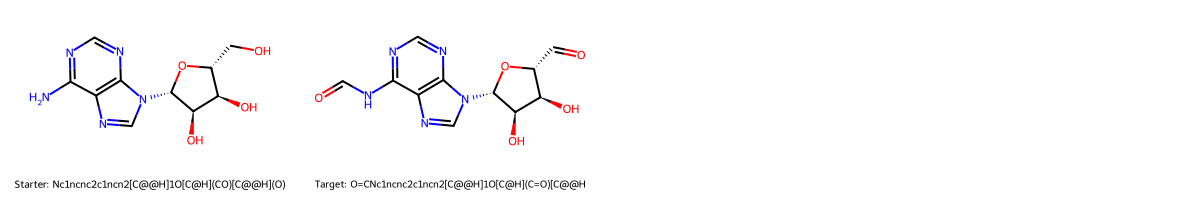

In [56]:
# Collect unique starters and target structures.
starterSmilesList = list({s.strip() for val in reconstructedPathwaysDF_OneCompound["starterSMILES"].dropna()
                          for s in str(val).split(";") if s.strip()})
targetSmilesList  = [bestSmiles]

allMolsForDisplay = [
    (smi, f"Starter: {smi[:40]}") for smi in starterSmilesList if Chem.MolFromSmiles(smi)
] + [
    (smi, f"Target: {smi[:40]}") for smi in targetSmilesList if Chem.MolFromSmiles(smi)
]

if allMolsForDisplay:
    mols    = [Chem.MolFromSmiles(s) for s,_ in allMolsForDisplay]
    legends = [l for _,l in allMolsForDisplay]
    display(Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(300,200), legends=legends))

### 3. Filter enzymatic reactions and score with DORA-XGB

Only reactions annotated as enzymatic by DORAnet are passed to DORA-XGB.
`feasibilityLabel_rule3` (the `add_concat` configuration) is the published
best-performing model.

In [57]:
enzymaticReactionDF = reconstructedPathwaysDF_OneCompound[
    reconstructedPathwaysDF_OneCompound["reactionType"].astype(str).str.lower()
    .str.contains("enzyme|enzymatic|bio|biological", na=False)
].copy()

print(f"Total reactions           : {len(reconstructedPathwaysDF_OneCompound):,}")
print(f"Likely enzymatic reactions: {len(enzymaticReactionDF):,}")
enzymaticReactionDF.head()

Total reactions           : 219
Likely enzymatic reactions: 219


,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,reactionType,rawNetworkReactionString,networkMatchStatus,numReactantMolecules,numProductMolecules,starterInReactants,targetInProducts,isReconstructedPathwayStep,routeStepId,fullReconstructedPathwayString
204,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,1,...,Enzymatic,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,matched_by_reaction_and_rule,1,2,False,True,True,high_pPotency_molecule_pathway12_wGen3_route_0...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...
205,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,1,...,Enzymatic,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,matched_by_reaction_and_rule,3,3,False,False,True,high_pPotency_molecule_pathway12_wGen3_route_0...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...
206,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,1,...,Enzymatic,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,matched_by_reaction_and_rule,2,2,True,False,True,high_pPotency_molecule_pathway12_wGen3_route_0...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...
207,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,2,...,Enzymatic,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,matched_by_reaction_and_rule,1,2,False,True,True,high_pPotency_molecule_pathway12_wGen3_route_0...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...
208,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,2,...,Enzymatic,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,matched_by_reaction_and_rule,2,2,False,False,True,high_pPotency_molecule_pathway12_wGen3_route_0...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...


In [58]:
reactionDF_DORAXGB = enzymaticReactionDF.copy()
reactionDF_DORAXGB["rxn_str"] = (
    reactionDF_DORAXGB["reactionString"].astype(str).str.replace(" ", "", regex=False)
)

def getFeasibilityScoresAndLabels(rxnStr):
    return pd.Series({
        "feasibilityScore_rule1": byDescMW_model.predict_proba(rxnStr),
        "feasibilityLabel_rule1": byDescMW_model.predict_label(rxnStr),
        "feasibilityScore_rule2": byAscMW_model.predict_proba(rxnStr),
        "feasibilityLabel_rule2": byAscMW_model.predict_label(rxnStr),
        "feasibilityScore_rule3": addConcat_model.predict_proba(rxnStr),
        "feasibilityLabel_rule3": addConcat_model.predict_label(rxnStr),
        "feasibilityScore_rule4": addSubtract_model.predict_proba(rxnStr),
        "feasibilityLabel_rule4": addSubtract_model.predict_label(rxnStr),
    })

scoreCols = [
    "feasibilityScore_rule1","feasibilityLabel_rule1",
    "feasibilityScore_rule2","feasibilityLabel_rule2",
    "feasibilityScore_rule3","feasibilityLabel_rule3",
    "feasibilityScore_rule4","feasibilityLabel_rule4",
]
reactionDF_DORAXGB[scoreCols] = reactionDF_DORAXGB["rxn_str"].progress_apply(getFeasibilityScoresAndLabels)
print("DORA-XGB scoring complete.")
reactionDF_DORAXGB[["reactionString","feasibilityScore_rule3","feasibilityLabel_rule3"]].head()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 219/219 [00:21<00:00, 10.37it/s]

DORA-XGB scoring complete.


,reactionString,feasibilityScore_rule3,feasibilityLabel_rule3
204,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,0.000110,0.0
205,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,0.257415,0.0
206,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.478300,0.0
207,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,0.000110,0.0
208,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,0.739067,1.0


In [59]:
# Rule3 (add_concat) is the published best model.
feasibilityLabel = "feasibilityLabel_rule3"
targetValue      = 1

reactionDF_DORAXGB_highFeasibility = (
    reactionDF_DORAXGB[
        (reactionDF_DORAXGB[feasibilityLabel] == targetValue)
        & (reactionDF_DORAXGB[feasibilityLabel].notna())
    ]
    .sort_values(feasibilityLabel, ascending=False)
    .reset_index(drop=True)
)

outPath = os.path.join(resultsDir, f"{target}_DORAXGB_highFeasibility_reactions.csv")
reactionDF_DORAXGB_highFeasibility.to_csv(outPath, index=False)
print(f"High-feasibility reactions: {len(reactionDF_DORAXGB_highFeasibility):,}")
print(f"Saved: {outPath}")
reactionDF_DORAXGB_highFeasibility.head()

High-feasibility reactions: 48
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/Ebola_DORAXGB_highFeasibility_reactions.csv


,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,fullReconstructedPathwayString,rxn_str,feasibilityScore_rule1,feasibilityLabel_rule1,feasibilityScore_rule2,feasibilityLabel_rule2,feasibilityScore_rule3,feasibilityLabel_rule3,feasibilityScore_rule4,feasibilityLabel_rule4
0,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,2,...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,0.754286,1.0,0.489343,0.0,0.739067,1.0,0.841001,1.0
1,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,3,...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.981449,1.0,0.998596,1.0,0.832501,1.0,0.471383,0.0
2,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,4,...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.981449,1.0,0.998596,1.0,0.832501,1.0,0.471383,0.0
3,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,4,...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1...,0.972314,1.0,0.961246,1.0,0.820338,1.0,0.919379,1.0
4,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,5,...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.981449,1.0,0.998596,1.0,0.832501,1.0,0.471383,0.0


### Print pathway-level details for high-feasibility reactions

In [60]:
if not reactionDF_DORAXGB_highFeasibility.empty:
    stepCountsDF_highFeasibility = (
        reactionDF_DORAXGB_highFeasibility
        .groupby(["targetSMILES","numSteps"])["routeId"]
        .nunique()
        .reset_index(name="numRoutes")
        .pivot_table(index="targetSMILES", columns="numSteps", values="numRoutes", fill_value=0)
        .reset_index()
    )
    stepCountsDF_highFeasibility.columns.name = None
    stepCountsDF_highFeasibility.columns = ["targetSMILES"] + [
        f"gen{c}_routes" for c in stepCountsDF_highFeasibility.columns[1:]
    ]
    stepCountsDF_highFeasibility["totalRoutes"] = stepCountsDF_highFeasibility.iloc[:,1:].sum(axis=1)
    print(stepCountsDF_highFeasibility.to_string())
else:
    print("No high-feasibility reactions found.")

                                          targetSMILES  gen3_routes  totalRoutes
0  O=CNc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O)[C@H]1O         40.0         40.0


### Summarize unique DORAnet rules in high-feasibility reactions

In [61]:
enzymaticReactionDF = reactionDF_DORAXGB_highFeasibility.copy()
ruleSummaryDF = (
    enzymaticReactionDF
    .groupby(["ruleName","reactionType"], dropna=False)
    .agg(
        numReactions=("reactionString","count"),
        exampleReaction=("reactionString","first"),
        exampleReactants=("reactants","first"),
        exampleProducts=("products","first"),
    )
    .reset_index()
    .sort_values("numReactions", ascending=False)
)
print(f"Unique DORAnet rules: {enzymaticReactionDF['ruleName'].nunique():,}")
ruleSummaryDF

Unique DORAnet rules: 2


,ruleName,reactionType,numReactions,exampleReaction,exampleReactants,exampleProducts
0,rule0042_10,Enzymatic,24,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...
1,rule0074_02,Enzymatic,24,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)...,CC(=O)Nc1ncnc2c1ncn2[C@@H]1O[C@H](C=O)[C@@H](O...


## 4. Extract UniProt IDs from the DORAnet reaction ruleset

In [62]:
doranetRulesetDF = pd.read_csv(doranetRulesetFile, sep="\t")
print(doranetRulesetDF.shape)
print(doranetRulesetDF.columns.tolist())
doranetRulesetDF.head()

(3604, 5)
['Name', 'Reactants', 'SMARTS', 'Products', 'Comments']


,Name,Reactants,SMARTS,Products,Comments
0,rule0001_01,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,Any;Any,P97259;P97402;Q08834;Q09328;Q16408;Q3V5L5;Q765...
1,rule0001_02,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,Any;Any,A0K8D0;A0KHH6;A0KZ10;A0L8R9;A0Q7X9;A1A7M6;A1K6...
2,rule0001_03,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,Any;Any,P0DMP6;P0DMP7;P16442;Q15951;Q1RLK6;Q3USF0;Q5HZ...
3,rule0001_04,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,Any;Any,A4IID1;O19071;O77836;P23336;P26572;P27115;P278...
4,rule0001_05,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,Any;Any,NaN


In [63]:
def splitUniProtIds(idString):
    if pd.isna(idString): return []
    return [x.strip() for x in str(idString).split(";") if x.strip()]

ruleInfoDF = doranetRulesetDF.rename(columns={
    "Name":"ruleName","Reactants":"ruleReactants",
    "SMARTS":"ruleSMARTS","Products":"ruleProducts","Comments":"candidateUniProtRaw",
}).copy()
ruleInfoDF["ruleName"]               = ruleInfoDF["ruleName"].astype(str).str.strip()
ruleInfoDF["candidateUniProtList"]   = ruleInfoDF["candidateUniProtRaw"].apply(splitUniProtIds)
ruleInfoDF["numCandidateUniProt"]    = ruleInfoDF["candidateUniProtList"].apply(len)
ruleInfoDF = ruleInfoDF[["ruleName","ruleReactants","ruleProducts","ruleSMARTS",
                          "candidateUniProtRaw","numCandidateUniProt"]].copy()
print(f"ruleInfoDF rows: {len(ruleInfoDF):,}")
ruleInfoDF

ruleInfoDF rows: 3,604


,ruleName,ruleReactants,ruleProducts,ruleSMARTS,candidateUniProtRaw,numCandidateUniProt
0,rule0001_01,Any;Any,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,P97259;P97402;Q08834;Q09328;Q16408;Q3V5L5;Q765...,10
1,rule0001_02,Any;Any,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,A0K8D0;A0KHH6;A0KZ10;A0L8R9;A0Q7X9;A1A7M6;A1K6...,263
2,rule0001_03,Any;Any,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,P0DMP6;P0DMP7;P16442;Q15951;Q1RLK6;Q3USF0;Q5HZ...,29
3,rule0001_04,Any;Any,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,A4IID1;O19071;O77836;P23336;P26572;P27115;P278...,42
4,rule0001_05,Any;Any,Any;Any,[#6;$([#6&R]1(-&!@[#8&!R]-&!@[#15&!R](=&!@[#8&...,NaN,0
...,...,...,...,...,...,...
3599,rule1152_1,Any;Any,Any;Any,[#6;$([#6&R]1-&@[#8&R]-&@[#6&R]-&@[#6&R](-&@[#...,Q8ZUN8,1
3600,rule1152_2,Any;Any,Any;Any,[#6;!$([#6&R]1-&@[#8&R]-&@[#6&R]-&@[#6&R](-&@[...,B9TTF1,1
3601,rule1164_1,Any;WATER,Any;H2O2,[#6;$([#6&!R]-&!@[#6&R]1:&@[#6&R]:&@[#6&R]:&@[...,Q972I2,1
3602,rule1165_1,Any;H2O2,Any;WATER,[#6;$([#6&!R]-[#6&R]1:&@[#6&R]:&@[#6&R]:&@[#6&...,Q972I2,1


In [64]:
reactionDF_wUniprotID = reactionDF_DORAXGB_highFeasibility.merge(ruleInfoDF, on="ruleName", how="left")
reactionDF_wUniprotID["hasRuleLookup"] = reactionDF_wUniprotID["ruleSMARTS"].notna()
print(reactionDF_wUniprotID["hasRuleLookup"].value_counts(dropna=False))
reactionDF_wUniprotID

hasRuleLookup
True    48
Name: count, dtype: int64


,dirName,jobName,sourceFolderNum,sourceDirectory,sourceDirectoryPath,sourceJsonName,sourceJsonPath,sourcePathwaysTxtPath,routeId,routeNumberInFile,...,feasibilityScore_rule3,feasibilityLabel_rule3,feasibilityScore_rule4,feasibilityLabel_rule4,ruleReactants,ruleProducts,ruleSMARTS,candidateUniProtRaw,numCandidateUniProt,hasRuleLookup
0,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,2,...,0.739067,1.0,0.841001,1.0,Any;O2,Any;H2O2,[#6;$([#6&!R]-&!@[#6&R]1-&@[#8&R]-&@[#6&R](-&@...,NaN,0,True
1,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,3,...,0.832501,1.0,0.471383,0.0,ACETYL-COA;Any,CoA;Any,[#6:1]-[#16:2].[#7;$([#7&!R]-[#6&R]);!$([#7&!R...,A9IH93;C7IZ16;CYP153A8;D2CFQ9;E3Q1H1;G3XD01;O1...,45,True
2,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,4,...,0.832501,1.0,0.471383,0.0,ACETYL-COA;Any,CoA;Any,[#6:1]-[#16:2].[#7;$([#7&!R]-[#6&R]);!$([#7&!R...,A9IH93;C7IZ16;CYP153A8;D2CFQ9;E3Q1H1;G3XD01;O1...,45,True
3,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,4,...,0.820338,1.0,0.919379,1.0,Any;O2,Any;H2O2,[#6;$([#6&!R]-&!@[#6&R]1-&@[#8&R]-&@[#6&R](-&@...,NaN,0,True
4,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,5,...,0.832501,1.0,0.471383,0.0,ACETYL-COA;Any,CoA;Any,[#6:1]-[#16:2].[#7;$([#7&!R]-[#6&R]);!$([#7&!R...,A9IH93;C7IZ16;CYP153A8;D2CFQ9;E3Q1H1;G3XD01;O1...,45,True
5,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,16,...,0.739067,1.0,0.841001,1.0,Any;O2,Any;H2O2,[#6;$([#6&!R]-&!@[#6&R]1-&@[#8&R]-&@[#6&R](-&@...,NaN,0,True
6,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,12,high_pPotency_molecule_pathway12_wGen3,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_network...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,/mnt/data.ese/nfs/users/sghosh6/DTRA_project/M...,high_pPotency_molecule_pathway12_wGen3_route_0...,17,...,0.832501,1.0,0.471383,0.0,ACETYL-COA;Any,CoA;Any,[#6:1]-[#16:2].[#7;$([#7&!R]-[#6&R]);!$([#7&!R...,A9IH93;C7IZ16;CYP153A8;D2CFQ9;E3Q1H1;G3XD01;O1...,45,True
7,high_pPotency_molecule_pathway12_wGen3,high_pPotency_molecule_pathway12_wGen3,

## 5. RCMFP enzyme retrieval

Find the best-matching natural enzyme for each DORAnet reaction by computing
Reaction Centre Morgan Fingerprint (RCMFP) Tanimoto similarity against a
precomputed reference database.

In [65]:
if ergochemicsSrc not in sys.path:
    sys.path.insert(0, ergochemicsSrc)

import ergochemics.mapping as egmap
import ergochemics.similarity as egsim

print("RDKit version:", rdBase.rdkitVersion)
print("ergochemics mapping file:", egmap.__file__)

_RDKit_MolToSmiles_original = rdmolfiles.MolToSmiles
def MolToSmiles_compat(mol, *args, **kwargs):
    kwargs.pop("ignoreAtomMapNumbers", None)
    return _RDKit_MolToSmiles_original(mol, *args, **kwargs)
Chem.MolToSmiles = MolToSmiles_compat
egmap.Chem.MolToSmiles = MolToSmiles_compat
egsim.Chem.MolToSmiles = MolToSmiles_compat

operator_map_reaction = egmap.operator_map_reaction
get_reaction_center   = egmap.get_reaction_center
ReactionFingerprinter = egsim.ReactionFingerprinter
MolFeaturizer         = egsim.MolFeaturizer

print("Patch test:", Chem.MolToSmiles(Chem.MolFromSmiles("[CH3:1][OH:2]"), ignoreAtomMapNumbers=True))

RDKit version: 2023.09.5
ergochemics mapping file: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/External/ergochemics/src/ergochemics/mapping.py
Patch test: [CH3:1][OH:2]


In [66]:
def normalize_reaction_string(rxn):
    if pd.isna(rxn): return None
    rxn = str(rxn).strip().replace(" ","")
    if rxn.count(">") == 2 and ">>" in rxn: return rxn
    parts = rxn.split(">")
    return f"{parts[0]}>>{parts[2]}" if len(parts)==3 else None

def map_query_reaction_with_rule(row):
    rxn, ruleSMARTS = row.get("queryReaction"), row.get("ruleSMARTS")
    if pd.isna(rxn) or str(rxn).strip()=="": return None, "missing_queryReaction"
    if pd.isna(ruleSMARTS) or str(ruleSMARTS).strip()=="": return None, "missing_ruleSMARTS"
    rxn, ruleSMARTS = str(rxn).replace(" ",""), str(ruleSMARTS).strip()
    if ">>" not in rxn: return None, "invalid_queryReaction_no_double_arrow"
    if ">>" not in ruleSMARTS: return None, "invalid_ruleSMARTS_no_double_arrow"
    lastError = None
    for explicitHs, statusLabel in [(False,"mapped"),(True,"mapped_explicit_h")]:
        try:
            result = operator_map_reaction(rxn=rxn, operator=ruleSMARTS, explicit_hs=explicitHs, quiet=True)
            if result.did_map and result.atom_mapped_smarts is not None:
                return result.atom_mapped_smarts, statusLabel
            lastError = f"{statusLabel}_failed"
        except Exception as e:
            lastError = str(e)
    return None, lastError or "mapping_failed"

TOP_K, MIN_SIMILARITY, FP_SIDE_LENGTH, FP_RADIUS = 20, 0.0, 2048, 2
reactionFingerprinter = ReactionFingerprinter(radius=FP_RADIUS, length=FP_SIDE_LENGTH, mol_featurizer=MolFeaturizer())

queryDF = reactionDF_wUniprotID.copy()
queryDF = queryDF[queryDF["hasRuleLookup"]].copy().reset_index(drop=True)
queryDF["queryReaction"] = queryDF["simplifiedReactionSMILES"].apply(normalize_reaction_string)
queryDF["queryRowId"]        = queryDF.index

print(f"Reactions to atom-map: {len(queryDF)}")

mappingResults = []
for _, row in tqdm(queryDF.iterrows(), total=len(queryDF), desc="Atom-mapping"):
    mappedSmarts, status = map_query_reaction_with_rule(row)
    mappingResults.append({"queryRowId":row["queryRowId"],"queryMappedReaction":mappedSmarts,"rcmfpMappingStatus":status})

mappingResultsDF = pd.DataFrame(mappingResults)
queryDF = queryDF.merge(mappingResultsDF, on="queryRowId", how="left")
queryDF["rcmfpStatus"] = queryDF["rcmfpMappingStatus"].apply(
    lambda s: "success" if s in ["mapped","mapped_explicit_h"] else "failed"
)

def computeRCMFP(mappedRxn):
    try:
        if pd.isna(mappedRxn) or str(mappedRxn).strip() == "":
            return None, "missing_mapped_reaction"
        mappedRxn = str(mappedRxn).replace(" ", "")
        if ">>" not in mappedRxn:
            return None, "invalid_mapped_reaction_no_double_arrow"
        if not pd.Series([mappedRxn]).str.contains(r":\d+\]", regex=True).iloc[0]:
            return None, "no_atom_map_labels"
        lrc, rrc = get_reaction_center(mappedRxn, mode="combined")
        if len(lrc) == 0 or len(rrc) == 0:
            return None, f"empty_reaction_center:lrc={len(lrc)}:rrc={len(rrc)}"
        fp = reactionFingerprinter.fingerprint(mappedRxn, output_type="bit", use_rc=True, rc_dist_ub=None)
        return fp.astype(bool), "rcmfp_success"
    except Exception as exc:
        return None, f"rcmfp_error:{type(exc).__name__}:{exc}"

rcmfpPairs = queryDF["queryMappedReaction"].progress_apply(computeRCMFP)
queryDF[["queryRCMFP", "rcmfpStatus"]] = pd.DataFrame(rcmfpPairs.tolist(), index=queryDF.index)

queryRcmfpFailureDF = queryDF[queryDF["queryRCMFP"].isna()].copy()
sucessAtomMapDF     = queryDF[queryDF["queryRCMFP"].notna()].copy().reset_index(drop=True)

print(f"Valid RCMFP: {len(sucessAtomMapDF)} | Failed: {len(queryRcmfpFailureDF)}")
if not queryRcmfpFailureDF.empty:
    print("Failure reasons:")
    print(queryRcmfpFailureDF["rcmfpStatus"].value_counts().to_string())

Reactions to atom-map: 48


  0%|                                                                                                               | 0/48 [00:00<?, ?it/s]

{0: 1, 1: 2, 2: 3, 3: 4, 4: 6, 5: 9, 6: 11, 7: 13, 8: 15, 9: 12, 10: 14, 11: 16, 12: 18, 13: 17, 14: 19, 15: 20, 16: 21, 17: 22, 18: 8, 19: 10, 20: 5, 21: 7, 22: 23, 23: 24}
[0, 1, 2, 3, 20, 4, 21, 18, 5, 19, 6, 9, 7, 10, 8, 11, 13, 12, 14, 15, 16, 17, 22, 23]
[1, 2, 23, 24]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 6, 5: 9, 6: 11, 7: 13, 8: 15, 9: 12, 10: 14, 11: 16, 12: 18, 13: 17, 14: 19, 15: 20, 16: 21, 17: 22, 18: 8, 19: 10, 20: 5, 21: 7, 22: 23, 23: 24}
[0, 1, 2, 3, 20, 4, 21, 18, 5, 19, 6, 9, 7, 10, 8, 11, 13, 12, 14, 15, 16, 17, 22, 23]
[1, 2, 23, 24]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 24: 25, 25: 26, 26: 27, 27: 28, 28: 29, 29: 31, 30: 34, 31: 37, 32: 42, 33: 44, 34: 38, 35: 43, 36: 45, 37: 47, 38: 46, 39: 48, 40: 32, 41: 35, 42: 30, 43: 33, 44: 36, 45: 39, 46: 40, 47: 41, 48: 49, 49: 50, 50: 53, 51: 54, 52: 56, 53: 59, 54: 57, 55: 55, 56: 58, 57: 61, 58

  8%|████████▌                                                                                              | 4/48 [00:00<00:01, 32.58it/s]

{0: 1, 1: 2, 2: 3, 3: 4, 4: 6, 5: 9, 6: 11, 7: 13, 8: 15, 9: 12, 10: 14, 11: 16, 12: 18, 13: 17, 14: 19, 15: 8, 16: 10, 17: 5, 18: 7, 19: 20, 20: 21}
[0, 1, 2, 3, 17, 4, 18, 15, 5, 16, 6, 9, 7, 10, 8, 11, 13, 12, 14, 19, 20]
[1, 2, 20, 21]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 6, 5: 9, 6: 11, 7: 13, 8: 15, 9: 12, 10: 14, 11: 16, 12: 18, 13: 17, 14: 19, 15: 8, 16: 10, 17: 5, 18: 7, 19: 20, 20: 21}
[0, 1, 2, 3, 17, 4, 18, 15, 5, 16, 6, 9, 7, 10, 8, 11, 13, 12, 14, 19, 20]
[1, 2, 20, 21]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 24: 25, 25: 26, 26: 27, 27: 28, 28: 29, 29: 31, 30: 34, 31: 37, 32: 42, 33: 44, 34: 38, 35: 43, 36: 45, 37: 47, 38: 46, 39: 48, 40: 32, 41: 35, 42: 30, 43: 33, 44: 36, 45: 39, 46: 40, 47: 41, 48: 49, 49: 50, 50: 53, 51: 54, 52: 56, 53: 59, 54: 57, 55: 55, 56: 58, 57: 61, 58: 60, 59: 62, 60: 63, 61: 65, 62: 68, 63: 70, 64: 66, 65: 69, 66: 64, 67

 17%|█████████████████▏                                                                                     | 8/48 [00:00<00:01, 29.95it/s]

{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 24: 25, 25: 26, 26: 27, 27: 28, 28: 29, 29: 31, 30: 34, 31: 37, 32: 42, 33: 44, 34: 38, 35: 43, 36: 45, 37: 47, 38: 46, 39: 48, 40: 32, 41: 35, 42: 30, 43: 33, 44: 36, 45: 39, 46: 40, 47: 41, 48: 49, 49: 50, 50: 53, 51: 54, 52: 56, 53: 59, 54: 57, 55: 55, 56: 58, 57: 61, 58: 60, 59: 62, 60: 63, 61: 65, 62: 68, 63: 70, 64: 66, 65: 69, 66: 64, 67: 67, 68: 51, 69: 52}
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 42, 29, 40, 43, 30, 41, 44, 31, 34, 45, 46, 47, 32, 35, 33, 36, 38, 37, 39, 48, 49, 68, 69, 50, 51, 55, 52, 54, 56, 53, 58, 57, 59, 60, 66, 61, 64, 67, 62, 65, 63]
[1, 49, 50]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 2

 25%|█████████████████████████▌                                                                            | 12/48 [00:00<00:01, 29.18it/s]

{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 24: 25, 25: 26, 26: 27, 27: 28, 28: 29, 29: 31, 30: 34, 31: 37, 32: 42, 33: 44, 34: 38, 35: 43, 36: 45, 37: 47, 38: 46, 39: 48, 40: 32, 41: 35, 42: 30, 43: 33, 44: 36, 45: 39, 46: 40, 47: 41, 48: 49, 49: 50, 50: 53, 51: 54, 52: 56, 53: 59, 54: 57, 55: 55, 56: 58, 57: 61, 58: 60, 59: 62, 60: 63, 61: 65, 62: 68, 63: 70, 64: 66, 65: 69, 66: 64, 67: 67, 68: 51, 69: 52}
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 42, 29, 40, 43, 30, 41, 44, 31, 34, 45, 46, 47, 32, 35, 33, 36, 38, 37, 39, 48, 49, 68, 69, 50, 51, 55, 52, 54, 56, 53, 58, 57, 59, 60, 66, 61, 64, 67, 62, 65, 63]
[1, 49, 50]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 2

 31%|███████████████████████████████▉                                                                      | 15/48 [00:00<00:01, 28.38it/s]

{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 24: 25, 25: 26, 26: 27, 27: 28, 28: 29, 29: 31, 30: 34, 31: 37, 32: 42, 33: 44, 34: 38, 35: 43, 36: 45, 37: 47, 38: 46, 39: 48, 40: 32, 41: 35, 42: 30, 43: 33, 44: 36, 45: 39, 46: 40, 47: 41, 48: 49, 49: 50, 50: 53, 51: 54, 52: 56, 53: 59, 54: 57, 55: 55, 56: 58, 57: 61, 58: 60, 59: 62, 60: 63, 61: 65, 62: 68, 63: 70, 64: 66, 65: 69, 66: 64, 67: 67, 68: 51, 69: 52}
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 42, 29, 40, 43, 30, 41, 44, 31, 34, 45, 46, 47, 32, 35, 33, 36, 38, 37, 39, 48, 49, 68, 69, 50, 51, 55, 52, 54, 56, 53, 58, 57, 59, 60, 66, 61, 64, 67, 62, 65, 63]
[1, 49, 50]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 2

 38%|██████████████████████████████████████▎                                                               | 18/48 [00:00<00:01, 24.39it/s]

{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 24: 25, 25: 26, 26: 27, 27: 28, 28: 29, 29: 31, 30: 34, 31: 37, 32: 42, 33: 44, 34: 38, 35: 43, 36: 45, 37: 47, 38: 46, 39: 48, 40: 32, 41: 35, 42: 30, 43: 33, 44: 36, 45: 39, 46: 40, 47: 41, 48: 49, 49: 50, 50: 53, 51: 54, 52: 56, 53: 59, 54: 57, 55: 55, 56: 58, 57: 61, 58: 60, 59: 62, 60: 63, 61: 65, 62: 68, 63: 70, 64: 66, 65: 69, 66: 64, 67: 67, 68: 51, 69: 52}
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 42, 29, 40, 43, 30, 41, 44, 31, 34, 45, 46, 47, 32, 35, 33, 36, 38, 37, 39, 48, 49, 68, 69, 50, 51, 55, 52, 54, 56, 53, 58, 57, 59, 60, 66, 61, 64, 67, 62, 65, 63]
[1, 49, 50]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 2

 44%|████████████████████████████████████████████▋                                                         | 21/48 [00:00<00:01, 22.49it/s]

{0: 1, 1: 2, 2: 3, 3: 4, 4: 6, 5: 9, 6: 11, 7: 13, 8: 15, 9: 12, 10: 14, 11: 16, 12: 18, 13: 17, 14: 19, 15: 20, 16: 21, 17: 22, 18: 8, 19: 10, 20: 5, 21: 7, 22: 23, 23: 24}
[0, 1, 2, 3, 20, 4, 21, 18, 5, 19, 6, 9, 7, 10, 8, 11, 13, 12, 14, 15, 16, 17, 22, 23]
[1, 2, 23, 24]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 6, 5: 9, 6: 11, 7: 13, 8: 15, 9: 12, 10: 14, 11: 16, 12: 18, 13: 17, 14: 19, 15: 20, 16: 21, 17: 22, 18: 8, 19: 10, 20: 5, 21: 7, 22: 23, 23: 24}
[0, 1, 2, 3, 20, 4, 21, 18, 5, 19, 6, 9, 7, 10, 8, 11, 13, 12, 14, 15, 16, 17, 22, 23]
[1, 2, 23, 24]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 24: 25, 25: 26, 26: 27, 27: 28, 28: 29, 29: 31, 30: 34, 31: 37, 32: 42, 33: 44, 34: 38, 35: 43, 36: 45, 37: 47, 38: 46, 39: 48, 40: 32, 41: 35, 42: 30, 43: 33, 44: 36, 45: 39, 46: 40, 47: 41, 48: 49, 49: 50, 50: 53, 51: 54, 52: 56, 53: 59, 54: 57, 55: 55, 56: 58, 57: 61, 58

 50%|███████████████████████████████████████████████████                                                   | 24/48 [00:00<00:01, 21.48it/s]

{0: 1, 1: 2, 2: 3, 3: 4, 4: 6, 5: 9, 6: 11, 7: 13, 8: 15, 9: 12, 10: 14, 11: 16, 12: 18, 13: 17, 14: 19, 15: 8, 16: 10, 17: 5, 18: 7, 19: 20, 20: 21}
[0, 1, 2, 3, 17, 4, 18, 15, 5, 16, 6, 9, 7, 10, 8, 11, 13, 12, 14, 19, 20]
[1, 2, 20, 21]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 6, 5: 9, 6: 11, 7: 13, 8: 15, 9: 12, 10: 14, 11: 16, 12: 18, 13: 17, 14: 19, 15: 8, 16: 10, 17: 5, 18: 7, 19: 20, 20: 21}
[0, 1, 2, 3, 17, 4, 18, 15, 5, 16, 6, 9, 7, 10, 8, 11, 13, 12, 14, 19, 20]
[1, 2, 20, 21]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 24: 25, 25: 26, 26: 27, 27: 28, 28: 29, 29: 31, 30: 34, 31: 37, 32: 42, 33: 44, 34: 38, 35: 43, 36: 45, 37: 47, 38: 46, 39: 48, 40: 32, 41: 35, 42: 30, 43: 33, 44: 36, 45: 39, 46: 40, 47: 41, 48: 49, 49: 50, 50: 53, 51: 54, 52: 56, 53: 59, 54: 57, 55: 55, 56: 58, 57: 61, 58: 60, 59: 62, 60: 63, 61: 65, 62: 68, 63: 70, 64: 66, 65: 69, 66: 64, 67

 58%|███████████████████████████████████████████████████████████▌                                          | 28/48 [00:01<00:00, 25.63it/s]

{0: 1, 1: 2, 2: 3, 3: 4, 4: 6, 5: 9, 6: 11, 7: 13, 8: 15, 9: 12, 10: 14, 11: 16, 12: 18, 13: 17, 14: 19, 15: 20, 16: 21, 17: 8, 18: 10, 19: 5, 20: 7, 21: 22, 22: 23}
[0, 1, 2, 3, 19, 4, 20, 17, 5, 18, 6, 9, 7, 10, 8, 11, 13, 12, 14, 15, 16, 21, 22]
[1, 2, 22, 23]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 6, 5: 9, 6: 11, 7: 13, 8: 15, 9: 12, 10: 14, 11: 16, 12: 18, 13: 17, 14: 19, 15: 20, 16: 21, 17: 8, 18: 10, 19: 5, 20: 7, 21: 22, 22: 23}
[0, 1, 2, 3, 19, 4, 20, 17, 5, 18, 6, 9, 7, 10, 8, 11, 13, 12, 14, 15, 16, 21, 22]
[1, 2, 22, 23]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 6, 5: 9, 6: 11, 7: 13, 8: 15, 9: 12, 10: 14, 11: 16, 12: 18, 13: 17, 14: 19, 15: 20, 16: 21, 17: 8, 18: 10, 19: 5, 20: 7, 21: 22, 22: 23}
[0, 1, 2, 3, 19, 4, 20, 17, 5, 18, 6, 9, 7, 10, 8, 11, 13, 12, 14, 15, 16, 21, 22]
[1, 2, 22, 23]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 6, 5: 9, 6: 11, 7: 13, 8: 15, 9: 12, 10: 14, 11: 16, 12: 18, 13: 17, 14: 19, 15: 20, 16: 21, 17: 8, 18: 10, 19: 5, 20: 7, 21: 22, 22: 23}
[0, 1, 2, 3, 19, 4, 20, 17, 5, 18, 6, 9, 7

 71%|████████████████████████████████████████████████████████████████████████▎                             | 34/48 [00:01<00:00, 33.49it/s]

{0: 1, 1: 2, 2: 3, 3: 4, 4: 6, 5: 9, 6: 11, 7: 13, 8: 15, 9: 12, 10: 14, 11: 16, 12: 18, 13: 17, 14: 19, 15: 20, 16: 21, 17: 8, 18: 10, 19: 5, 20: 7, 21: 22, 22: 23}
[0, 1, 2, 3, 19, 4, 20, 17, 5, 18, 6, 9, 7, 10, 8, 11, 13, 12, 14, 15, 16, 21, 22]
[1, 2, 22, 23]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 6, 5: 9, 6: 11, 7: 13, 8: 15, 9: 12, 10: 14, 11: 16, 12: 18, 13: 17, 14: 19, 15: 20, 16: 21, 17: 8, 18: 10, 19: 5, 20: 7, 21: 22, 22: 23}
[0, 1, 2, 3, 19, 4, 20, 17, 5, 18, 6, 9, 7, 10, 8, 11, 13, 12, 14, 15, 16, 21, 22]
[1, 2, 22, 23]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 6, 5: 9, 6: 11, 7: 13, 8: 15, 9: 12, 10: 14, 11: 16, 12: 18, 13: 17, 14: 19, 15: 20, 16: 21, 17: 8, 18: 10, 19: 5, 20: 7, 21: 22, 22: 23}
[0, 1, 2, 3, 19, 4, 20, 17, 5, 18, 6, 9, 7, 10, 8, 11, 13, 12, 14, 15, 16, 21, 22]
[1, 2, 22, 23]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 6, 5: 9, 6: 11, 7: 13, 8: 15, 9: 12, 10: 14, 11: 16, 12: 18, 13: 17, 14: 19, 15: 20, 16: 21, 17: 8, 18: 10, 19: 5, 20: 7, 21: 22, 22: 23}
[0, 1, 2, 3, 19, 4, 20, 17, 5, 18, 6, 9, 7

 79%|████████████████████████████████████████████████████████████████████████████████▊                     | 38/48 [00:01<00:00, 32.67it/s]

{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 24: 25, 25: 26, 26: 27, 27: 28, 28: 29, 29: 31, 30: 34, 31: 37, 32: 42, 33: 44, 34: 38, 35: 43, 36: 45, 37: 47, 38: 46, 39: 48, 40: 32, 41: 35, 42: 30, 43: 33, 44: 36, 45: 39, 46: 40, 47: 41, 48: 49, 49: 50, 50: 53, 51: 54, 52: 56, 53: 59, 54: 57, 55: 55, 56: 58, 57: 61, 58: 60, 59: 62, 60: 63, 61: 65, 62: 68, 63: 70, 64: 66, 65: 69, 66: 64, 67: 67, 68: 51, 69: 52}
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 42, 29, 40, 43, 30, 41, 44, 31, 34, 45, 46, 47, 32, 35, 33, 36, 38, 37, 39, 48, 49, 68, 69, 50, 51, 55, 52, 54, 56, 53, 58, 57, 59, 60, 66, 61, 64, 67, 62, 65, 63]
[1, 49, 50]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 2

 88%|█████████████████████████████████████████████████████████████████████████████████████████▎            | 42/48 [00:01<00:00, 29.88it/s]

{0: 1, 1: 2, 2: 3, 3: 4, 4: 6, 5: 9, 6: 11, 7: 13, 8: 15, 9: 12, 10: 14, 11: 16, 12: 18, 13: 17, 14: 19, 15: 8, 16: 10, 17: 5, 18: 7, 19: 20, 20: 21}
[0, 1, 2, 3, 17, 4, 18, 15, 5, 16, 6, 9, 7, 10, 8, 11, 13, 12, 14, 19, 20]
[1, 2, 20, 21]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 6, 5: 9, 6: 11, 7: 13, 8: 15, 9: 12, 10: 14, 11: 16, 12: 18, 13: 17, 14: 19, 15: 8, 16: 10, 17: 5, 18: 7, 19: 20, 20: 21}
[0, 1, 2, 3, 17, 4, 18, 15, 5, 16, 6, 9, 7, 10, 8, 11, 13, 12, 14, 19, 20]
[1, 2, 20, 21]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 24: 25, 25: 26, 26: 27, 27: 28, 28: 29, 29: 31, 30: 34, 31: 37, 32: 42, 33: 44, 34: 38, 35: 43, 36: 45, 37: 47, 38: 46, 39: 48, 40: 32, 41: 35, 42: 30, 43: 33, 44: 36, 45: 39, 46: 40, 47: 41, 48: 49, 49: 50, 50: 53, 51: 54, 52: 56, 53: 59, 54: 57, 55: 55, 56: 58, 57: 61, 58: 60, 59: 62, 60: 63, 61: 65, 62: 68, 63: 70, 64: 66, 65: 69, 66: 64, 67

 96%|█████████████████████████████████████████████████████████████████████████████████████████████████▊    | 46/48 [00:01<00:00, 30.06it/s]

{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 24: 25, 25: 26, 26: 27, 27: 28, 28: 29, 29: 31, 30: 34, 31: 37, 32: 42, 33: 44, 34: 38, 35: 43, 36: 45, 37: 47, 38: 46, 39: 48, 40: 32, 41: 35, 42: 30, 43: 33, 44: 36, 45: 39, 46: 40, 47: 41, 48: 49, 49: 50, 50: 53, 51: 54, 52: 56, 53: 59, 54: 57, 55: 55, 56: 58, 57: 61, 58: 60, 59: 62, 60: 63, 61: 65, 62: 68, 63: 70, 64: 66, 65: 69, 66: 64, 67: 67, 68: 51, 69: 52}
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 42, 29, 40, 43, 30, 41, 44, 31, 34, 45, 46, 47, 32, 35, 33, 36, 38, 37, 39, 48, 49, 68, 69, 50, 51, 55, 52, 54, 56, 53, 58, 57, 59, 60, 66, 61, 64, 67, 62, 65, 63]
[1, 49, 50]
{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 2

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 48/48 [00:01<00:00, 27.63it/s]

Valid RCMFP: 48 | Failed: 0


In [67]:
naturalEnzymeDF = pd.read_parquet(knownEnzymeParquetFile)
naturalEnzymeDF_wFP = np.load(knownEnzymeFpFile, allow_pickle=True)
naturalEnzyme_fingerprint_matrix = naturalEnzymeDF_wFP["fingerprints"].astype(bool)
naturalEnzyme_RC_PatternLHS  = naturalEnzymeDF_wFP["rc_patterns_lhs"]
naturalEnzyme_RC_PatternRHS  = naturalEnzymeDF_wFP["rc_patterns_rhs"]
knownValidIndices             = naturalEnzymeDF_wFP["valid_indices"]
naturalEnzymeReferenceDF      = naturalEnzymeDF.iloc[knownValidIndices].reset_index(drop=True).copy()
naturalEnzymeReferenceDF["naturalEnzyme_RC_PatternLHS"] = naturalEnzyme_RC_PatternLHS
naturalEnzymeReferenceDF["naturalEnzyme_RC_PatternRHS"] = naturalEnzyme_RC_PatternRHS
naturalEnzymeReferenceDF["knownOriginalIndex"]          = knownValidIndices
print("Known enzyme reference shape:", naturalEnzymeReferenceDF.shape)
print("Fingerprint matrix shape:", naturalEnzyme_fingerprint_matrix.shape)

Known enzyme reference shape: (54063, 25)
Fingerprint matrix shape: (54063, 4096)


In [68]:
def make_reverse_fingerprint_matrix(fpMatrix, sideLength=FP_SIDE_LENGTH):
    return np.hstack([fpMatrix[:, sideLength:], fpMatrix[:, :sideLength]]).astype(bool)

def make_fingerprint_matrix_from_column(df, fpCol):
    validMask = df[fpCol].notna()
    metaDF    = df.loc[validMask].drop(columns=[fpCol], errors="ignore").reset_index(drop=True)
    fpMatrix  = np.vstack(df.loc[validMask, fpCol].to_numpy()).astype(bool)
    fpReverse = make_reverse_fingerprint_matrix(fpMatrix)
    return metaDF, fpMatrix, fpReverse, fpMatrix.sum(axis=1), fpReverse.sum(axis=1)

def get_rule_base(x):
    return None if pd.isna(x) else str(x).strip().split("_")[0]

def parse_operator_list(x):
    if isinstance(x, np.ndarray): return [str(v).strip() for v in x.tolist() if v is not None and str(v).strip()]
    if isinstance(x, (list,tuple,set)): return [str(v).strip() for v in x if v is not None and str(v).strip()]
    if x is None or pd.isna(x): return []
    s = str(x).strip()
    if s in ["","nan","None","[]"]: return []
    try:
        parsed = ast.literal_eval(s)
        return [str(v).strip() for v in list(parsed)] if isinstance(parsed,(list,tuple,set,np.ndarray)) else [str(parsed).strip()]
    except Exception:
        for sep in ["|",";",","]:
            if sep in s: return [v.strip().strip("'").strip('"') for v in s.split(sep) if v.strip()]
        return [s]

def choose_known_rule_base(row):
    top = row.get("top_mapped_operator")
    if top is not None and not pd.isna(top) and str(top).strip().startswith("rule"):
        return str(top).strip(), "top_mapped_operator"
    for op in parse_operator_list(row.get("all_mapped_operators")):
        if str(op).startswith("rule"): return str(op), "all_mapped_operators"
    return None, "no_ruleBase"

queryMetaDF, query_FP_Matrix, query_FP_MatrixReverse, queryPopcounts, queryReversePopcounts =     make_fingerprint_matrix_from_column(sucessAtomMapDF, "queryRCMFP")

naturalEnzyme_fingerprint_matrixReverse = make_reverse_fingerprint_matrix(naturalEnzyme_fingerprint_matrix)
knownPopcounts        = naturalEnzyme_fingerprint_matrix.sum(axis=1)
knownReversePopcounts = naturalEnzyme_fingerprint_matrixReverse.sum(axis=1)

queryKeepCols = [c for c in ["reactants","products","reactionString","ruleName","reactionType",
                              "rxn_str","ruleSMARTS","candidateUniProtRaw","numCandidateUniProt",
                              "hasRuleLookup","queryReaction","queryMappedReaction","rcmfpMappingStatus",
                              "rcmfpStatus","feasibilityScore_rule1","feasibilityLabel_rule1",
                              "feasibilityScore_rule2","feasibilityLabel_rule2",
                              "feasibilityScore_rule3","feasibilityLabel_rule3",
                              "feasibilityScore_rule4","feasibilityLabel_rule4"] if c in queryMetaDF.columns]
queryMetaDF   = queryMetaDF[queryKeepCols].copy() if queryKeepCols else queryMetaDF

naturalEnzymeReferenceDF["_ruleBase"] = naturalEnzymeReferenceDF.apply(
    lambda row: choose_known_rule_base(row)[0], axis=1
)
queryMetaDF["_ruleKey"] = queryMetaDF["ruleName"].apply(get_rule_base)

knownIndicesByRuleBase = {}
for idx, row in naturalEnzymeReferenceDF.iterrows():
    rb = row.get("_ruleBase")
    if pd.notna(rb) and rb:
        knownIndicesByRuleBase.setdefault(rb, []).append(idx)
for k in knownIndicesByRuleBase:
    knownIndicesByRuleBase[k] = np.array(knownIndicesByRuleBase[k])

knownMetaDF = naturalEnzymeReferenceDF.copy()
popcount8   = np.array([bin(i).count("1") for i in range(256)], dtype=np.float32)

def pack_matrix(matrix):
    return np.packbits(matrix.astype(np.uint8), axis=1)

queryPacked = pack_matrix(query_FP_Matrix)
knownPacked = pack_matrix(naturalEnzyme_fingerprint_matrix)
knownPackedReverse = pack_matrix(naturalEnzyme_fingerprint_matrixReverse)

def compute_tanimoto_similarity(queryPackedRow, queryPop, refPackedMatrix, refPopcounts):
    inter = popcount8[np.bitwise_and(refPackedMatrix, queryPackedRow)].sum(axis=1).astype(np.float32)
    union = refPopcounts + queryPop - inter
    scores = np.zeros(len(refPopcounts), dtype=np.float32)
    valid  = union > 0; scores[valid] = inter[valid] / union[valid]
    return scores

def retrieve_similar_reactions(queryIdx, topK=TOP_K, minSimilarity=MIN_SIMILARITY):
    queryRuleBase = queryMetaDF.loc[queryIdx, "_ruleKey"]
    if pd.notna(queryRuleBase) and queryRuleBase in knownIndicesByRuleBase:
        candidateIdx = knownIndicesByRuleBase[queryRuleBase]; searchMode = "same_ruleBase"
    else:
        candidateIdx = np.arange(len(knownMetaDF)); searchMode = "full_database_fallback"
    qPacked = queryPacked[queryIdx]; qPop = queryPopcounts[queryIdx]
    scores = np.maximum(
        compute_tanimoto_similarity(qPacked, qPop, knownPacked[candidateIdx], knownPopcounts[candidateIdx]),
        compute_tanimoto_similarity(qPacked, qPop, knownPackedReverse[candidateIdx], knownReversePopcounts[candidateIdx])
    )
    topLocalIdx = np.argsort(scores)[::-1][:topK]
    topGlobalIdx = candidateIdx[topLocalIdx]
    topScores    = scores[topLocalIdx]
    rows = []
    for rank, (globalIdx, score) in enumerate(zip(topGlobalIdx, topScores), start=1):
        if score < minSimilarity: break
        known = knownMetaDF.loc[globalIdx].to_dict()
        known.update({"queryRowId":queryIdx,"knownRowId":globalIdx,"rcmfpSimilarity":float(score),
                      "rank":rank,"searchMode":searchMode})
        rows.append(known)
    return rows

print("Running RCMFP enzyme retrieval...")
allMatchRows = []
for queryIdx in tqdm(range(len(queryMetaDF)), desc="RCMFP retrieval"):
    allMatchRows.extend(retrieve_similar_reactions(queryIdx))

matchedRCMFP_DF = pd.DataFrame(allMatchRows)
if not matchedRCMFP_DF.empty:
    matchedRCMFP_DF["ruleName"] = matchedRCMFP_DF["queryRowId"].map(queryMetaDF["ruleName"])
print(f"RCMFP matches: {len(matchedRCMFP_DF)}")

Running RCMFP enzyme retrieval...


RCMFP retrieval: 100%|████████████████████████████████████████████████████████████████████████████████████| 48/48 [00:00<00:00, 488.21it/s]

RCMFP matches: 960


In [69]:
def classify_precedent(sim):
    if pd.isna(sim): return "No natural precedent retrieved"
    if sim >= 0.60:  return "Strong natural enzyme precedent"
    if sim >= 0.35:  return "Moderate natural enzyme precedent"
    if sim > 0:      return "Weak precedent; likely enzyme-engineering risk"
    return "No useful RCMFP precedent"

uniprotPattern = re.compile(
    r"([OPQ][0-9][A-Z0-9]{3}[0-9]|[A-NR-Z][0-9](?:[A-Z0-9]{3}[0-9]){1,2})"
)
def extractUniProtID(x):
    if pd.isna(x): return []
    ids = uniprotPattern.findall(str(x))
    seen, out = set(), []
    for uid in ids:
        if uid not in seen: out.append(uid); seen.add(uid)
    return out

tmp = matchedRCMFP_DF.copy()
tmp["knownProteinRefList"] = tmp["protein_refs"].apply(extractUniProtID)
tmp = tmp[tmp["knownProteinRefList"].apply(len) > 0].copy()
tmp = tmp.explode("knownProteinRefList").rename(columns={"knownProteinRefList":"rcmfpSupportedUniProt"})
tmp["rcmfpSimilarity"] = pd.to_numeric(tmp["rcmfpSimilarity"], errors="coerce")
tmp["rank"]            = pd.to_numeric(tmp["rank"], errors="coerce")

ruleRcmfpUniProtScoreDF = (
    tmp.groupby(["ruleName","rcmfpSupportedUniProt"])
    .agg(numSupportingHits=("knownRowId","nunique"),
         bestRCMFPSimilarity=("rcmfpSimilarity","max"),
         meanRCMFPSimilarity=("rcmfpSimilarity","mean"),
         bestRank=("rank","min"))
    .reset_index()
)
ruleRcmfpUniProtScoreDF["rcmfpProteinRefScore"] = (
    ruleRcmfpUniProtScoreDF["numSupportingHits"] * ruleRcmfpUniProtScoreDF["bestRCMFPSimilarity"]
)

bestRCMFPUniProtByRuleDF = (
    ruleRcmfpUniProtScoreDF
    .sort_values(["ruleName","rcmfpProteinRefScore","bestRCMFPSimilarity"],
                 ascending=[True,False,False])
    .drop_duplicates(subset=["ruleName"], keep="first")
    .reset_index(drop=True)
)

uniprotPerRuleDF = (
    reactionDF_wUniprotID[["ruleName","candidateUniProtRaw"]]
    .drop_duplicates("ruleName")
    .assign(numUniqueUniProt=lambda df: df["candidateUniProtRaw"]
            .apply(lambda x: len(splitUniProtIds(x))))
)
bestUniprotPerRuleDF = bestRCMFPUniProtByRuleDF.copy()
print("Best UniProt ID per rule:")
print(bestUniprotPerRuleDF[["ruleName","rcmfpSupportedUniProt","bestRCMFPSimilarity"]].head(10).to_string())

Best UniProt ID per rule:
      ruleName rcmfpSupportedUniProt  bestRCMFPSimilarity
0  rule0042_10                P11245             0.102094
1  rule0074_02                Q7ZA32             0.103896


In [70]:
rename_map = {
    "rcmfpSupportedUniProt": "bestRCMFP_UniProtID",
    "rcmfpProteinRefScore":  "bestRCMFP_UniProtScore",
    "bestRCMFPSimilarity":   "bestRCMFP_SimilarityScore",
    "meanRCMFPSimilarity":   "meanRCMFP_Similarity_byRule",
    "numSupportingHits":     "numRCMFP_SupportingHits_byRule",
    "bestRank":              "bestRCMFPRank_byRule",
}
bestRCMFPForMergeDF = (
    bestRCMFPUniProtByRuleDF[["ruleName", *rename_map]].rename(columns=rename_map)
)

reactionDF_wBestRCMFP_Similarity = (
    reactionDF_wUniprotID
    .merge(bestRCMFPForMergeDF, on="ruleName", how="left")
    .assign(hasbestRCMFP_UniProtID=lambda df:
            df["bestRCMFP_UniProtID"].fillna("").astype(str).str.len().gt(0))
)
print(f"Rows after RCMFP merge: {len(reactionDF_wBestRCMFP_Similarity):,}")

dropCols = [c for c in ["reactantSetCan","productSetCan"] if c in reactionDF_wBestRCMFP_Similarity.columns]
reactionDF_wBestRCMFP_Similarity = reactionDF_wBestRCMFP_Similarity.drop(columns=dropCols, errors="ignore")

bestUniprotPerRuleDF_display = (
    bestUniprotPerRuleDF
    .merge(uniprotPerRuleDF, on="ruleName", how="inner")
    [["ruleName","numUniqueUniProt","rcmfpSupportedUniProt","bestRCMFPSimilarity"]]
    .sort_values("numUniqueUniProt", ascending=False)
    .reset_index(drop=True)
)
bestUniprotPerRuleDF_display

Rows after RCMFP merge: 48


,ruleName,numUniqueUniProt,rcmfpSupportedUniProt,bestRCMFPSimilarity
0,rule0042_10,45,P11245,0.102094
1,rule0074_02,0,Q7ZA32,0.103896


## 6. Fetch UniProt metadata (EC numbers, protein names, organisms, sequences)

In [71]:
def chunkList(lst, n):
    for i in range(0, len(lst), n): yield lst[i:i+n]

def cleanUniProtAccession(x):
    if pd.isna(x): return None
    m = re.match(r"([OPQ][0-9][A-Z0-9]{3}[0-9]|[A-NR-Z][0-9](?:[A-Z0-9]{3}[0-9]){1,2})", str(x).strip())
    return m.group(1) if m else None

def fetchUniProtBatch(accessions, fields="accession,protein_name,organism_name,ec,sequence"):
    query = "+OR+".join(f"accession:{acc}" for acc in accessions)
    url   = f"https://rest.uniprot.org/uniprotkb/stream?format=tsv&query={query}&fields={fields}"
    try:
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        return pd.read_csv(StringIO(resp.text), sep="\t")
    except Exception as e:
        print(f"UniProt fetch error: {e}"); return pd.DataFrame()

# Build the prioritized UniProt list.
tmp = reactionDF_wBestRCMFP_Similarity.copy()
tmp["prioritizedUniProt"] = (
    tmp["bestRCMFP_UniProtID"].fillna("").astype(str)
    .where(lambda s: s.str.len() > 0, other=tmp.get("candidateUniProtRaw",""))
)
allUniProtRaw = (
    tmp["prioritizedUniProt"].dropna()
    .str.split("[;,]").explode().str.strip().dropna()
    .apply(cleanUniProtAccession).dropna().unique().tolist()
)
print(f"Unique UniProt accessions to fetch: {len(allUniProtRaw)}")

uniprotRows = []
for chunk in tqdm(list(chunkList(allUniProtRaw, 50)), desc="Fetching UniProt"):
    batchDF = fetchUniProtBatch(chunk)
    if not batchDF.empty: uniprotRows.append(batchDF)

uniprotMetaDF = pd.concat(uniprotRows, ignore_index=True) if uniprotRows else pd.DataFrame()
if not uniprotMetaDF.empty:
    uniprotMetaDF = uniprotMetaDF.rename(columns={
        "Entry":"uniprotAccession","Protein names":"proteinName",
        "Organism":"organism","EC number":"ecNumber","Sequence":"proteinSequence"
    })
print(f"UniProt metadata fetched: {len(uniprotMetaDF)} entries")
uniprotMetaDF.head()

Unique UniProt accessions to fetch: 2


Fetching UniProt: 100%|██████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.09it/s]

UniProt metadata fetched: 2 entries


,uniprotAccession,proteinName,organism,ecNumber,proteinSequence
0,P11245,Arylamine N-acetyltransferase 2 (EC 2.3.1.5) (...,Homo sapiens (Human),2.3.1.118; 2.3.1.5,MDIEAYFERIGYKNSRNKLDLETLTDILEHQIRAVPFENLNMHCGQ...
1,Q7ZA32,Pyranose 2-oxidase (EC 1.1.3.10) (FAD-oxidored...,Trametes ochracea (White-rot fungus) (Trametes...,1.1.3.10,MSTSSSDPFFNFAKSSFRSAAAQKASASSLPPLPGPDKKVPGMDIK...


## 7. Fetch DNA sequences from GenBank and codon-optimize with DNA Chisel

In [72]:
ncbiSleepSeconds    = 0.40 if NCBI_API_KEY is None else 0.12
uniprotSleepSeconds = 0.15
maxUniProtToFetch   = None  # set to 20 for a test run, None for the full run

uniprotAccessionPattern = re.compile(
    r"^([OPQ][0-9][A-Z0-9]{3}[0-9]|[A-NR-Z][0-9]([A-Z0-9]{3}[0-9]){1,2})$"
)

def isValidUniProtAccession(x):
    return False if pd.isna(x) else bool(
        uniprotAccessionPattern.match(str(x).strip())
    )


def dedupeKeepOrder(valueList):
    seen, out = set(), []
    for value in valueList:
        if value is None: continue
        value = str(value).strip()
        if value and value not in seen:
            out.append(value); seen.add(value)
    return out


def parseFastaRecords(fastaText):
    records, header, seqLines = [], None, []
    for line in str(fastaText).splitlines():
        line = line.strip()
        if not line: continue
        if line.startswith(">"):
            if header is not None:
                records.append({"header": header, "sequence": "".join(seqLines)})
            header = line[1:]; seqLines = []
        else:
            seqLines.append(line)
    if header is not None:
        records.append({"header": header, "sequence": "".join(seqLines)})
    return records


def cleanDnaSequence(seq):
    return re.sub(r"[^ACGTN]", "", str(seq).upper())


def fetchUniProtCrossRefs(uniprotAccession, sleepSeconds=0.15):
    url = f"https://rest.uniprot.org/uniprotkb/{uniprotAccession}.json"
    result = {"uniprotAccession": uniprotAccession,
               "refseqProteinIds": [], "emblProteinIds": [], "nucleotideIds": [],
               "rawCrossRefSummary": "", "uniprotCrossRefStatus": "not_queried",
               "uniprotCrossRefError": ""}
    try:
        response = requests.get(url, timeout=60)
        if response.status_code != 200:
            result["uniprotCrossRefStatus"] = "failed"
            result["uniprotCrossRefError"]  = f"{response.status_code}: {response.text[:300]}"
            time.sleep(sleepSeconds); return result
        crossRefs       = response.json().get("uniProtKBCrossReferences", [])
        refseqProteinIds, emblProteinIds, nucleotideIds, rawSummaryParts = [], [], [], []
        for xref in crossRefs:
            db, xrefId = str(xref.get("database","")), str(xref.get("id",""))
            propDict = {}
            for p in xref.get("properties", []):
                propDict.setdefault(str(p.get("key","")), []).append(str(p.get("value","")))
            if db in ["RefSeq","EMBL","GenBank","DDBJ"]:
                rawSummaryParts.append(f"{db}:{xrefId}")
            if db == "RefSeq" and xrefId:
                refseqProteinIds.append(xrefId)
            if db in ["EMBL","GenBank","DDBJ"]:
                if xrefId: nucleotideIds.append(xrefId)
                for key, vals in propDict.items():
                    nk = key.lower().replace(" ","").replace("_","").replace("-","")
                    if "proteinid" in nk or nk == "protein":
                        emblProteinIds.extend(vals)
                    if "nucleotidesequenceid" in nk or "nucleotide" in nk:
                        nucleotideIds.extend(vals)
        result["refseqProteinIds"]  = dedupeKeepOrder(refseqProteinIds)
        result["emblProteinIds"]    = dedupeKeepOrder(emblProteinIds)
        result["nucleotideIds"]     = dedupeKeepOrder(nucleotideIds)
        result["rawCrossRefSummary"] = ";".join(rawSummaryParts)
        result["uniprotCrossRefStatus"] = "success"
    except Exception as exc:
        result["uniprotCrossRefStatus"] = "failed"
        result["uniprotCrossRefError"]  = str(exc)
    time.sleep(sleepSeconds); return result


def fetchNcbiCdsFromProteinAccession(proteinAccession, sleepSeconds=0.40):
    params = {"db":"protein","id":proteinAccession,"rettype":"fasta_cds_na",
              "retmode":"text","tool":NCBI_TOOL,"email":NCBI_EMAIL}
    if NCBI_API_KEY: params["api_key"] = NCBI_API_KEY
    result = {"proteinAccessionQueried": proteinAccession, "ncbiFetchStatus": "not_queried",
               "ncbiFetchError": "", "genbankCdsFastaHeader": "", "genbankCdsSequence": "",
               "genbankCdsLengthBp": np.nan, "numFastaRecordsReturned": 0}
    try:
        response = requests.get("https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi",
                                params=params, timeout=120)
        if response.status_code != 200:
            result["ncbiFetchStatus"] = "failed"
            result["ncbiFetchError"]  = f"{response.status_code}: {response.text[:300]}"
            time.sleep(sleepSeconds); return result
        fastaRecords = parseFastaRecords(response.text.strip())
        if not fastaRecords:
            result["ncbiFetchStatus"] = "no_cds_returned"
            result["ncbiFetchError"]  = response.text[:300]
            time.sleep(sleepSeconds); return result
        cleanSeq = cleanDnaSequence(fastaRecords[0]["sequence"])
        if not cleanSeq:
            result["ncbiFetchStatus"] = "empty_cds_sequence"
            result["ncbiFetchError"]  = "No valid DNA sequence parsed."
            time.sleep(sleepSeconds); return result
        result.update({"ncbiFetchStatus": "success",
                        "genbankCdsFastaHeader": fastaRecords[0]["header"],
                        "genbankCdsSequence": cleanSeq,
                        "genbankCdsLengthBp": len(cleanSeq),
                        "numFastaRecordsReturned": len(fastaRecords)})
    except Exception as exc:
        result["ncbiFetchStatus"] = "failed"; result["ncbiFetchError"] = str(exc)
    time.sleep(sleepSeconds); return result


def fetchBestGenBankCdsForUniProt(uniprotAccession):
    crossRef = fetchUniProtCrossRefs(uniprotAccession, sleepSeconds=uniprotSleepSeconds)
    candidateIds = dedupeKeepOrder(crossRef["refseqProteinIds"] + crossRef["emblProteinIds"])
    output = {"uniprotAccession": uniprotAccession,
               "genbankProteinIdsFromUniProt": ";".join(candidateIds),
               "genbankNucleotideIdsFromUniProt": ";".join(crossRef["nucleotideIds"]),
               "rawCrossRefSummary": crossRef["rawCrossRefSummary"],
               "uniprotCrossRefStatus": crossRef["uniprotCrossRefStatus"],
               "uniprotCrossRefError": crossRef["uniprotCrossRefError"],
               "genbankProteinAccessionUsed": "", "genbankCdsFastaHeader": "",
               "genbankCdsSequence": "", "genbankCdsLengthBp": np.nan,
               "numFastaRecordsReturned": 0,
               "genbankCdsFetchStatus": "not_attempted", "genbankCdsFetchError": ""}
    if not candidateIds:
        output["genbankCdsFetchStatus"] = "no_protein_crossref"
        output["genbankCdsFetchError"]  = "No RefSeq/EMBL/GenBank protein cross-reference in UniProt JSON."
        return output
    fetchErrors = []
    for proteinAcc in candidateIds:
        cdsResult = fetchNcbiCdsFromProteinAccession(proteinAcc, sleepSeconds=ncbiSleepSeconds)
        if cdsResult["ncbiFetchStatus"] == "success":
            output.update({"genbankProteinAccessionUsed": proteinAcc,
                            "genbankCdsFastaHeader": cdsResult["genbankCdsFastaHeader"],
                            "genbankCdsSequence": cdsResult["genbankCdsSequence"],
                            "genbankCdsLengthBp": cdsResult["genbankCdsLengthBp"],
                            "numFastaRecordsReturned": cdsResult["numFastaRecordsReturned"],
                            "genbankCdsFetchStatus": "success", "genbankCdsFetchError": ""})
            return output
        fetchErrors.append(f"{proteinAcc}: {cdsResult['ncbiFetchStatus']} | {cdsResult['ncbiFetchError']}")
    output["genbankCdsFetchStatus"] = "failed_all_protein_crossrefs"
    output["genbankCdsFetchError"]  = " || ".join(fetchErrors[:5])
    return output


# Select UniProt accessions from the RCMFP merge result.
uniqueUniProtForGenBankList = sorted(
    reactionDF_wBestRCMFP_Similarity["bestRCMFP_UniProtID"]
    .apply(cleanUniProtAccession).dropna()
    .apply(lambda x: x if isValidUniProtAccession(x) else None).dropna()
    .unique().tolist()
)
if maxUniProtToFetch is not None:
    uniqueUniProtForGenBankList = uniqueUniProtForGenBankList[:maxUniProtToFetch]
print(f"Unique UniProt accessions for GenBank CDS fetch: {len(uniqueUniProtForGenBankList):,}")

genbankLookupRecords = []
for acc in tqdm(uniqueUniProtForGenBankList, desc="Fetching GenBank CDS via UniProt crossrefs"):
    genbankLookupRecords.append(fetchBestGenBankCdsForUniProt(acc))

genbankLookupDF = pd.DataFrame(genbankLookupRecords)
print("\nGenBank CDS fetch status:")
print(genbankLookupDF["genbankCdsFetchStatus"].value_counts(dropna=False))

reactionDF_wBestRCMFP_wDNAseq = reactionDF_wBestRCMFP_Similarity.merge(
    genbankLookupDF, left_on="bestRCMFP_UniProtID", right_on="uniprotAccession", how="left"
)
reactionDF_wBestRCMFP_wDNAseq["hasGenBankCdsSequence"] = (
    reactionDF_wBestRCMFP_wDNAseq["genbankCdsSequence"].fillna("").astype(str).str.len() > 0
)
before = len(reactionDF_wBestRCMFP_wDNAseq)
reactionDF_wBestRCMFP_wDNAseq = reactionDF_wBestRCMFP_wDNAseq[
    reactionDF_wBestRCMFP_wDNAseq["hasGenBankCdsSequence"]
].reset_index(drop=True)
print(f"\nRows with GenBank CDS: {len(reactionDF_wBestRCMFP_wDNAseq)} / {before}")

Unique UniProt accessions for GenBank CDS fetch: 2


Fetching GenBank CDS via UniProt crossrefs: 100%|████████████████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.74s/it]


GenBank CDS fetch status:
genbankCdsFetchStatus
success    2
Name: count, dtype: int64

Rows with GenBank CDS: 48 / 48


In [73]:
targetSpecies = "e_coli"
minGc = 0.30; maxGc = 0.70; gcWindow = 50; stopCodon = "TAA"
stopCodons = {"TAA","TAG","TGA"}

forbiddenPatternList = [
    "GGTACC","AAGCTT","GCGGCCGC","GAATTC","CTCGAG","CCCGGG",
    "GGATCC","TCTAGA","ACTAGT","ACGCGT","GAAGAC","GTCTTC",
]

def cleanDna(seq):
    if pd.isna(seq): return ""
    return re.sub(r"[^ACGTN]","",str(seq).upper())

def removeTerminalStop(cds):
    cds = cleanDna(cds)
    if len(cds) >= 3 and len(cds) % 3 == 0 and cds[-3:] in stopCodons:
        return cds[:-3]
    return cds

def hasInternalStop(cds):
    cds = cleanDna(cds)
    if len(cds) % 3 != 0: return True
    return any(cds[i:i+3] in stopCodons for i in range(0, len(cds), 3))

def classifyCdsForOptimization(cds):
    cds = cleanDna(cds)
    cdsNoStop = removeTerminalStop(cds)
    if len(cds) == 0: return "no_cds"
    if len(cdsNoStop) == 0: return "empty_after_stop_removal"
    if len(cdsNoStop) % 3 != 0: return "length_not_multiple_of_3"
    if "N" in cdsNoStop: return "contains_N"
    if hasInternalStop(cdsNoStop): return "contains_internal_stop"
    return "ready_for_optimization"

def safeText(x):
    if pd.isna(x): return ""
    return re.sub(r"[^A-Za-z0-9_.-]+","_",str(x))[:80]

def wrapFasta(seq, width=80):
    return "\n".join(str(seq)[i:i+width] for i in range(0, len(str(seq)), width))

def optimizeCds(cdsRaw, targetSpecies, minGc, maxGc, gcWindow, forbiddenPatterns, stopCodon):
    cdsNoStop = removeTerminalStop(cleanDna(cdsRaw))
    constraints = [
        EnforceTranslation(start_codon="keep"),
        EnforceGCContent(mini=minGc, maxi=maxGc, window=gcWindow),
        *[AvoidPattern(p) for p in forbiddenPatterns],
    ]
    objectives = [MaximizeCAI(species=targetSpecies)]
    problem = DnaOptimizationProblem(sequence=cdsNoStop, constraints=constraints, objectives=objectives)
    try:
        problem.resolve_constraints()
        problem.optimize()
        return problem.sequence + stopCodon, "optimized"
    except Exception as e:
        return None, f"optimization_failed: {e}"

df = reactionDF_wBestRCMFP_wDNAseq.copy()
df["cdsClass"] = df["genbankCdsSequence"].apply(classifyCdsForOptimization)

optimizationRows = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Codon optimizing"):
    cdsRaw = row.get("genbankCdsSequence","")
    cdsClass = row.get("cdsClass","")
    if cdsClass != "ready_for_optimization":
        optimizationRows.append({"ruleName":row.get("ruleName"),"hasOptimizedCds":False,
                          "optimizedCds":None,"optimizedCdsLengthBp":np.nan,
                          "expressionHost":targetSpecies,"optimizationStatus":cdsClass,
                          "optimizationInputKey":None,"optimizedGeneId":None})
        continue
    inputKey = hashlib.md5(cleanDna(cdsRaw).encode()).hexdigest()[:12]
    optCds, status = optimizeCds(cdsRaw, targetSpecies, minGc, maxGc, gcWindow,
                                  forbiddenPatternList, stopCodon)
    uniprotAcc = row.get("bestRCMFP_UniProtID","")
    geneId = f"opt_{safeText(uniprotAcc)}_{safeText(row.get('ruleName',''))}_{inputKey}"
    optimizationRows.append({"ruleName":row.get("ruleName"),"hasOptimizedCds":optCds is not None,
                          "optimizedCds":optCds,
                          "optimizedCdsLengthBp":len(optCds) if optCds is not None else np.nan,
                          "expressionHost":targetSpecies,"optimizationStatus":status,
                          "optimizationInputKey":inputKey,"optimizedGeneId":geneId,
                          "uniprotAccession":uniprotAcc,
                          "genbankProteinAccessionUsed":row.get("genbankProteinAccessionUsed",""),
                          "ecNumber":row.get("ecNumber","")})

optimizationDF = pd.DataFrame(optimizationRows)
reactionDF_wOptimizedDNAseq = df.merge(optimizationDF.drop(columns=["ruleName"],errors="ignore"),
                                        left_index=True, right_index=True, how="left")

successCount = optimizationDF["hasOptimizedCds"].sum()
print(f"Successfully optimized: {successCount} / {len(optimizationDF)}")

constraint:   0%|                                                                 | 0/13 [00:00<?, ?it/s, now=AvoidPattern[0-1869](patt...]

location:   0%|                                                                                            | 0/1 [00:00<?, ?it/s, now=None]

location:   0%|                                                                                      | 0/1 [00:00<?, ?it/s, now=394-400(+)]

                                                                                                                                           

location:   0%|                                                                                      | 0/1 [00:00<?, ?it/s, now=394-400(+)]

location:   0%|                                                                                        | 0/1 [00:00<?, ?it/s, now=11-17(+)]

                                                                                                                                           

location:   0

Successfully optimized: 48 / 48


In [74]:
reactionDF_wOptimizedDNAseq_display = (
    bestUniprotPerRuleDF_display[["ruleName"]]
    .merge(reactionDF_wOptimizedDNAseq[
        ["ruleName","bestRCMFP_UniProtID","optimizedCds","optimizedCdsLengthBp","expressionHost","optimizationStatus"]
    ].drop_duplicates("ruleName"), on="ruleName", how="left")
    .reset_index(drop=True)
)
reactionDF_wOptimizedDNAseq_display

,ruleName,bestRCMFP_UniProtID,optimizedCds,optimizedCdsLengthBp,expressionHost,optimizationStatus
0,rule0042_10,P11245,ATGGATATTGAAGCGTATTTTGAACGCATTGGCTATAAAAACAGCC...,873,e_coli,optimized
1,rule0074_02,Q7ZA32,ATGAGCACCAGCAGCAGCGATCCGTTTTTTAACTTTGCGAAAAGCA...,1872,e_coli,optimized


## 8. Export DNA design files

In [75]:
optimizedDNAFilePath = os.path.join(resultsDir,
                                        f"{target}_reactionDF_wBestRCMFP_optimized_Ecoli.fasta")

fastaDF = (
    reactionDF_wOptimizedDNAseq[reactionDF_wOptimizedDNAseq["hasOptimizedCds"]]
    .drop_duplicates("optimizationInputKey")
    .copy()
)

with open(optimizedDNAFilePath, "w", encoding="utf-8") as f:
    for _, row in fastaDF.iterrows():
        header = (
            f">{row.get('optimizedGeneId','')}|"
            f"rule={safeText(row.get('ruleName',''))}|"
            f"UniProt={safeText(row.get('uniprotAccession',''))}|"
            f"GenBankProtein={safeText(row.get('genbankProteinAccessionUsed',''))}|"
            f"EC={safeText(row.get('ecNumber',''))}|"
            f"host=Escherichia_coli"
        )
        f.write(header + "\n")
        f.write(wrapFasta(row["optimizedCds"]) + "\n\n")

print(f"Saved FASTA: {optimizedDNAFilePath}")
print(f"Sequences  : {len(fastaDF)}")

Saved FASTA: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/Ebola_reactionDF_wBestRCMFP_optimized_Ecoli.fasta
Sequences  : 2


## 9. Pathway visualisation

In [76]:
maxPerStep  = 10
subImgSize  = (280, 210)
pngSubImgSize = (500, 380)
pngDpi      = (300, 300)

def loadFont(size):
    for path in [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
        "/usr/share/fonts/truetype/freefont/FreeSansBold.ttf",
    ]:
        try: return ImageFont.truetype(path, size)
        except Exception: continue
    return ImageFont.load_default()

separatorFont = loadFont(52)
labelFont     = loadFont(18)
headerFont    = loadFont(22)

def splitPathway(pathwayStr):
    return [] if pd.isna(pathwayStr) else [x.strip() for x in str(pathwayStr).split("||") if x.strip()]

def splitStarters(starterStr):
    return [] if pd.isna(starterStr) else [x.strip() for x in str(starterStr).split(";") if x.strip()]

def safeName(rawName):
    return re.sub(r"[^A-Za-z0-9._-]+","_",str(rawName))

def rdkitImageToPil(imageObj):
    if isinstance(imageObj, Image.Image): return imageObj.convert("RGB")
    if isinstance(imageObj, (bytes,bytearray)): return Image.open(BytesIO(imageObj)).convert("RGB")
    if hasattr(imageObj,"data"): return Image.open(BytesIO(imageObj.data)).convert("RGB")
    raise TypeError(f"Unexpected image type: {type(imageObj)}")

def molFromSmiles(smi):
    try: return Chem.MolFromSmiles(str(smi))
    except Exception: return None

def renderMolPil(smi, size):
    mol = molFromSmiles(smi)
    if mol is None: return Image.new("RGB", size, "white")
    drawer = Draw.MolDraw2DCairo(*size)
    drawer.DrawMolecule(mol)
    drawer.FinishDrawing()
    return Image.open(BytesIO(drawer.GetDrawingText())).convert("RGB")

def makeArrowImg(height, width=60, color="black"):
    img = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(img)
    midY  = height // 2
    arrowW = 12
    draw.line([(5, midY), (width-arrowW-5, midY)], fill=color, width=3)
    draw.polygon([(width-arrowW-5, midY-5), (width-5, midY), (width-arrowW-5, midY+5)], fill=color)
    return img

def makePathwayImage(stepSmilesList, starterSmilesList, targetSmiles, subImgSize):
    allSmiles = starterSmilesList + stepSmilesList + [targetSmiles]
    imgs = []
    for i, smi in enumerate(allSmiles):
        molImg = renderMolPil(smi, subImgSize)
        imgs.append(molImg)
        if i < len(allSmiles) - 1:
            imgs.append(makeArrowImg(subImgSize[1]))
    totalW = sum(img.width for img in imgs)
    totalH = subImgSize[1]
    canvas = Image.new("RGB", (totalW, totalH), "white")
    x = 0
    for img in imgs:
        canvas.paste(img, (x, 0)); x += img.width
    return canvas

pathwayVizDir = os.path.join(resultsDir, "PathwayFigures/")
os.makedirs(pathwayVizDir, exist_ok=True)

if not reactionDF_wOptimizedDNAseq.empty:
    uniqueRoutes = reactionDF_wOptimizedDNAseq["routeId"].dropna().unique()[:maxPerStep]
    for routeId in uniqueRoutes:
        routeDF = (
            reactionDF_wOptimizedDNAseq[reactionDF_wOptimizedDNAseq["routeId"]==routeId]
            .sort_values("step")
        )
        stepSmilesList  = routeDF["products"].tolist()
        starterSmilesList = splitStarters(routeDF["starterSMILES"].iloc[0])
        targetSmiles      = str(routeDF["targetSMILES"].iloc[0])
        try:
            img = makePathwayImage(stepSmilesList, starterSmilesList, targetSmiles, subImgSize)
            savePathPng = os.path.join(pathwayVizDir, f"{safeName(routeId)}.png")
            savePathPdf = os.path.join(pathwayVizDir, f"{safeName(routeId)}.pdf")
            img.save(savePathPng, dpi=pngDpi)
            img.save(savePathPdf, dpi=pngDpi)
        except Exception as e:
            print(f"[skip] {routeId}: {e}")
    print(f"Saved pathway figures to: {pathwayVizDir}")
else:
    print("No optimized DNA sequences to visualize.")

Saved pathway figures to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/SynThera/Ebola/Results_Ebola/PathwayFigures/
